In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, balanced_accuracy_score, log_loss, roc_auc_score
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('dataset/customer_clusters_with_features.csv') # file csv xuất từ df_existing (trước khi encoded) và gắn label
df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Monetary,R,F,M,RFM_Segment,RFM_Score,RFM_Level,Cluster,KMeans_Raw_Cluster,Customer_Tag
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,...,1144,1,1,1,111,3,Lost,1,2,Low Value
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,...,1291,1,1,1,111,3,Lost,1,2,Low Value
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,...,1887,1,1,1,111,3,Lost,1,2,Low Value
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,...,1171,4,1,1,411,6,Potential,1,2,Low Value
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,...,816,1,1,1,111,3,Lost,1,2,Low Value


In [3]:
df[(df['Months_Inactive_12_mon']==2.0) & (df['Cluster'] == 3)] 

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Monetary,R,F,M,RFM_Segment,RFM_Score,RFM_Level,Cluster,KMeans_Raw_Cluster,Customer_Tag
808,41,M,2,Unknown,Single,$60K - $80K,Blue,24,6,2,...,3663,2,2,2,222,6,Potential,3,0,At Risk
869,34,M,2,Uneducated,Single,$80K - $120K,Blue,36,3,2,...,2295,2,2,1,221,5,Lost,3,2,At Risk
890,26,M,0,College,Divorced,Less than $40K,Blue,36,5,2,...,2483,2,3,2,232,7,Potential,3,2,At Risk
929,54,M,2,High School,Married,$80K - $120K,Blue,50,4,2,...,2489,2,2,2,222,6,Potential,3,2,At Risk
1059,34,M,2,College,Married,$80K - $120K,Blue,22,4,2,...,2962,2,2,2,222,6,Potential,3,2,At Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7623,40,M,3,Post-Graduate,Single,$120K +,Blue,26,1,2,...,6453,2,4,4,244,10,Champions,3,3,At Risk
7631,50,M,3,College,Unknown,$60K - $80K,Blue,42,1,2,...,8272,2,3,4,234,9,Loyal,3,3,At Risk
7656,50,M,2,Graduate,Single,$80K - $120K,Silver,35,1,2,...,7745,2,4,4,244,10,Champions,3,3,At Risk
7660,53,M,3,Graduate,Unknown,$40K - $60K,Blue,48,2,2,...,7766,2,4,4,244,10,Champions,3,3,At Risk


In [4]:
df[df['Cluster'] == 3].value_counts()

Customer_Age  Gender  Dependent_count  Education_Level  Marital_Status  Income_Category  Card_Category  Months_on_book  Total_Relationship_Count  Months_Inactive_12_mon  Contacts_Count_12_mon  Credit_Limit  Total_Revolving_Bal  Total_Amt_Chng_Q4_Q1  Total_Trans_Amt  Total_Trans_Ct  Total_Ct_Chng_Q4_Q1  Avg_Utilization_Ratio  Last_Activity_Date  Recency  Frequency  Monetary  R  F  M  RFM_Segment  RFM_Score  RFM_Level  Cluster  KMeans_Raw_Cluster  Customer_Tag
26            F       0                Graduate         Single          $40K - $60K      Blue           13              5                         1                       2                      5655.0        0                    0.842                 2312             61              0.649                0.000                  2023-01-03          177      61         2312      1  2  1  121          4          Lost       3        2                   At Risk         1
                                                                     

In [5]:
print(f"Kích thước ban đầu: {df.shape}")

Kích thước ban đầu: (8500, 31)


In [6]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
df.isnull().sum()

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
Last_Activity_Date          0
Recency                     0
Frequency                   0
Monetary                    0
R                           0
F                           0
M                           0
RFM_Segment                 0
RFM_Score                   0
RFM_Level                   0
Cluster                     0
KMeans_Raw_Cluster          0
Customer_Tag                0
dtype: int64

In [8]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,Cluster,KMeans_Raw_Cluster
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.0000,8500.0000,8500.0000,8500.0000,8500.000000,8500.000000,8500.000000
mean,46.262118,2.335412,35.880588,3.914588,2.273765,2.356353,8726.877518,1256.604118,0.772510,4654.655882,68.672588,0.742434,0.296412,127.227176,68.672588,4654.655882,2.5000,2.5000,2.5000,277.5000,7.500000,1.306941,0.884353
std,8.081157,1.303229,8.021810,1.528949,1.016741,1.081436,9084.969807,757.745354,0.217783,3512.772635,22.919011,0.228054,0.272568,31.286297,22.919011,3512.772635,1.1181,1.1181,1.1181,112.5037,2.412683,1.220688,1.033235
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,0.256000,816.000000,11.000000,0.028000,0.000000,1.000000,11.000000,816.000000,1.0000,1.0000,1.0000,111.0000,3.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,1.000000,2.000000,2602.000000,800.000000,0.643000,2384.750000,54.000000,0.617000,0.055000,107.000000,54.000000,2384.750000,1.7500,1.7500,1.7500,194.2500,6.000000,0.000000,0.000000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4643.500000,1364.000000,0.743000,4100.000000,71.000000,0.721000,0.211000,127.000000,71.000000,4100.000000,2.5000,2.5000,2.5000,277.5000,8.000000,1.000000,0.000000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11252.750000,1807.000000,0.860000,4781.250000,82.000000,0.833000,0.529250,152.000000,82.000000,4781.250000,3.2500,3.2500,3.2500,360.7500,9.000000,3.000000,2.000000
max,73.000000,5.000000,56.000000,6.000000,6.000000,5.000000,34516.000000,2517.000000,3.397000,18484.000000,139.000000,3.714000,0.994000,179.000000,139.000000,18484.000000,4.0000,4.0000,4.0000,444.0000,12.000000,3.000000,3.000000


In [9]:
df_existing = df.copy()

In [10]:
df_existing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              8500 non-null   int64  
 1   Gender                    8500 non-null   object 
 2   Dependent_count           8500 non-null   int64  
 3   Education_Level           8500 non-null   object 
 4   Marital_Status            8500 non-null   object 
 5   Income_Category           8500 non-null   object 
 6   Card_Category             8500 non-null   object 
 7   Months_on_book            8500 non-null   int64  
 8   Total_Relationship_Count  8500 non-null   int64  
 9   Months_Inactive_12_mon    8500 non-null   int64  
 10  Contacts_Count_12_mon     8500 non-null   int64  
 11  Credit_Limit              8500 non-null   float64
 12  Total_Revolving_Bal       8500 non-null   int64  
 13  Total_Amt_Chng_Q4_Q1      8500 non-null   float64
 14  Total_Tr

In [11]:
df_existing['Last_Activity_Date'] = pd.to_datetime(df_existing['Last_Activity_Date'], format='%Y-%m-%d')

In [12]:
df_existing.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Last_Activity_Date,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,RFM_Level,Cluster,KMeans_Raw_Cluster,Customer_Tag
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,1.335,1144,42,1.625,0.061,2023-01-04,176,42,1144,1,1,1,111,3,Lost,1,2,Low Value
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,1.541,1291,33,3.714,0.105,2023-01-01,179,33,1291,1,1,1,111,3,Lost,1,2,Low Value
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,2.594,1887,20,2.333,0.000,2023-01-01,179,20,1887,1,1,1,111,3,Lost,1,2,Low Value
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,1.405,1171,20,2.333,0.760,2023-04-03,87,20,1171,4,1,1,411,6,Potential,1,2,Low Value
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,2.175,816,28,2.500,0.000,2023-01-03,177,28,816,1,1,1,111,3,Lost,1,2,Low Value


In [13]:
RANDOM_STATE = 42
DROP_COLS = [
    # engineered RFM (if present)
    "Recency", "Frequency", "Monetary",
    # scored RFM/segments (if present)
    "R", "F", "M",
    "RFM_Score", "RFM_Level", "RFM_Segment", "RFM_Cluster",
    # any date columns used to make recency
    "Last_Activity_Date",
    # other leakage-ish / not for training
    "KMeans_Raw_Cluster",
    "Customer_Tag"
]

TARGET_COL = "Cluster"

df = df_existing.copy()

# X, y
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL] + DROP_COLS, errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"\nPhân bố y_train:\n{y_train.value_counts().sort_index()}")
print(f"\nPhân bố y_test:\n{y_test.value_counts().sort_index()}")

X_train: (6800, 18), y_train: (6800,)
X_test: (1700, 18), y_test: (1700,)

Phân bố y_train:
Cluster
0    2452
1    1699
2     758
3    1891
Name: count, dtype: int64

Phân bố y_test:
Cluster
0    613
1    425
2    190
3    472
Name: count, dtype: int64


In [14]:
X.columns.tolist()

['Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

### Preprocessing

In [15]:
# unique values in categorical columns
for col in X.select_dtypes(include=['object']).columns:
    unique_values = X[col].unique()
    print(f"Column '{col}' has {len(unique_values)} unique values: {unique_values}\n")

Column 'Gender' has 2 unique values: ['M' 'F']

Column 'Education_Level' has 7 unique values: ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']

Column 'Marital_Status' has 4 unique values: ['Married' 'Single' 'Unknown' 'Divorced']

Column 'Income_Category' has 6 unique values: ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Column 'Card_Category' has 4 unique values: ['Blue' 'Gold' 'Silver' 'Platinum']



In [16]:
ordinal_cols = ["Card_Category", "Income_Category", "Education_Level"]

card_order = ["Blue", "Silver", "Gold", "Platinum"]
income_order = ["Unknown", "Less than $40K", "$40K - $60K", "$60K - $80K", "$80K - $120K", "$120K +"]
edu_order = ["Unknown", "Uneducated", "High School", "College", "Graduate", "Post-Graduate", "Doctorate"]

ordinal_categories = [card_order, income_order, edu_order]

nominal_cols = ["Gender", "Marital_Status"]

numeric_cols = [c for c in X.columns if c not in ordinal_cols + nominal_cols]

base_preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ), ordinal_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop"
)

We need to scale our data using StandardScaler because Logistic Regression is very sensitive to feature scale. Without scaling, features with larger values can dominate the learning process, making the model unable to learn properly from smaller-scale features.

StandardScaler means that all features are on the similar scale and each feature contributes fairly to the model

In [17]:
# Pipeline cho Logistic Regression
logistic_pipeline = Pipeline([
    ("preprocessor", base_preprocessor),
    ("scaler", StandardScaler()), 
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        multi_class='multinomial',  # because of multi-class clusters
        solver='lbfgs'
    ))
])

print("✓ Pipeline Logistic Regression already set up.")

✓ Pipeline Logistic Regression already set up.


Key parameters: `max_iter=1000` allows enough iterations for convergence (default 100 is often insufficient), `random_state=42` ensures reproducibility, `multi_class='multinomial'` optimizes all classes simultaneously (best for multi-class problems), and `solver='lbfgs'` is an efficient optimization algorithm. The model uses default L2 regularization with `C=1.0` to prevent overfitting, which will be tuned later with Optuna.

### Train Model

In [18]:
print("Training Logistic Regression...")
logistic_pipeline.fit(X_train, y_train)
print("✓ Logistic Regression model trained.")

Training Logistic Regression...
✓ Logistic Regression model trained.


c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Performance Evaluation

In [19]:
def evaluate_model(model, X_train, y_train, X_test, y_test, label="MODEL"):
    """
    Evaluate model performance on train and test sets
    
    Parameters:
    -----------
    model : trained model/pipeline
    X_train, y_train : training data
    X_test, y_test : test data
    label : model label for display
    
    Returns:
    --------
    dict : dictionary containing all metrics
    """
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'train': {
            'accuracy': accuracy_score(y_train, y_pred_train),
            'f1_macro': f1_score(y_train, y_pred_train, average='macro'),
            'f1_weighted': f1_score(y_train, y_pred_train, average='weighted'),
            'balanced_accuracy': balanced_accuracy_score(y_train, y_pred_train)
        },
        'test': {
            'accuracy': accuracy_score(y_test, y_pred_test),
            'f1_macro': f1_score(y_test, y_pred_test, average='macro'),
            'f1_weighted': f1_score(y_test, y_pred_test, average='weighted'),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_test)
        }
    }
    
    # Print results
    print("="*60)
    print(f"{label} - PERFORMANCE EVALUATION")
    print("="*60)
    
    print("\n--- TRAIN SET ---")
    print(f"Accuracy:          {metrics['train']['accuracy']:.4f}")
    print(f"F1-Macro:          {metrics['train']['f1_macro']:.4f}")
    print(f"F1-Weighted:       {metrics['train']['f1_weighted']:.4f}")
    print(f"Balanced Accuracy: {metrics['train']['balanced_accuracy']:.4f}")
    
    print("\n--- TEST SET ---")
    print(f"Accuracy:          {metrics['test']['accuracy']:.4f}")
    print(f"F1-Macro:          {metrics['test']['f1_macro']:.4f}")
    print(f"F1-Weighted:       {metrics['test']['f1_weighted']:.4f}")
    print(f"Balanced Accuracy: {metrics['test']['balanced_accuracy']:.4f}")
    
    # Classification Report
    print("\n--- CLASSIFICATION REPORT (TEST) ---")
    print(classification_report(y_test, y_pred_test))
    
    # Confusion Matrix
    print("\n--- CONFUSION MATRIX (TEST) ---")
    cm = confusion_matrix(y_test, y_pred_test)
    labels = sorted(y_test.unique())
    
    cm_df = pd.DataFrame(
        cm,
        index=[f'True: {lbl}' for lbl in labels],
        columns=[f'Pred: {lbl}' for lbl in labels]
    )
    print(cm_df)
    
    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Confusion Matrix
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'Confusion Matrix - {label}')
    axes[0].set_ylabel('Actual Cluster')
    axes[0].set_xlabel('Predicted Cluster')
    
    # Plot 2: Metrics Comparison
    metrics_names = ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Balanced Acc']
    train_scores = [
        metrics['train']['accuracy'],
        metrics['train']['f1_macro'],
        metrics['train']['f1_weighted'],
        metrics['train']['balanced_accuracy']
    ]
    test_scores = [
        metrics['test']['accuracy'],
        metrics['test']['f1_macro'],
        metrics['test']['f1_weighted'],
        metrics['test']['balanced_accuracy']
    ]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    axes[1].bar(x - width/2, train_scores, width, label='Train', alpha=0.8, color='skyblue')
    axes[1].bar(x + width/2, test_scores, width, label='Test', alpha=0.8, color='coral')
    axes[1].set_ylabel('Score')
    axes[1].set_title(f'Performance Metrics - {label}')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics_names, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    # Additional metrics if predict_proba available
    if hasattr(model, "predict_proba"):
        y_proba_test = model.predict_proba(X_test)
        
        print("\n--- PROBABILITY-BASED METRICS (TEST) ---")
        ll = log_loss(y_test, y_proba_test)
        print(f"Log Loss: {ll:.4f}")
        
        try:
            auc = roc_auc_score(y_test, y_proba_test, multi_class="ovr", average="macro")
            print(f"ROC-AUC (OvR, macro): {auc:.4f}")
            metrics['test']['log_loss'] = ll
            metrics['test']['roc_auc'] = auc
        except Exception as e:
            print(f"ROC-AUC calculation failed: {e}")
    
    print("\n" + "="*60)
    
    return metrics

Logistic Regression (Baseline) - PERFORMANCE EVALUATION

--- TRAIN SET ---
Accuracy:          0.9066
F1-Macro:          0.9213
F1-Weighted:       0.9068
Balanced Accuracy: 0.9270

--- TEST SET ---
Accuracy:          0.8900
F1-Macro:          0.9068
F1-Weighted:       0.8903
Balanced Accuracy: 0.9141

--- CLASSIFICATION REPORT (TEST) ---
              precision    recall  f1-score   support

           0       0.96      0.77      0.85       613
           1       0.97      0.99      0.98       425
           2       0.96      0.97      0.97       190
           3       0.75      0.93      0.83       472

    accuracy                           0.89      1700
   macro avg       0.91      0.91      0.91      1700
weighted avg       0.90      0.89      0.89      1700


--- CONFUSION MATRIX (TEST) ---
         Pred: 0  Pred: 1  Pred: 2  Pred: 3
True: 0      470        3        4      136
True: 1        0      419        0        6
True: 2        2        0      185        3
True: 3       20 

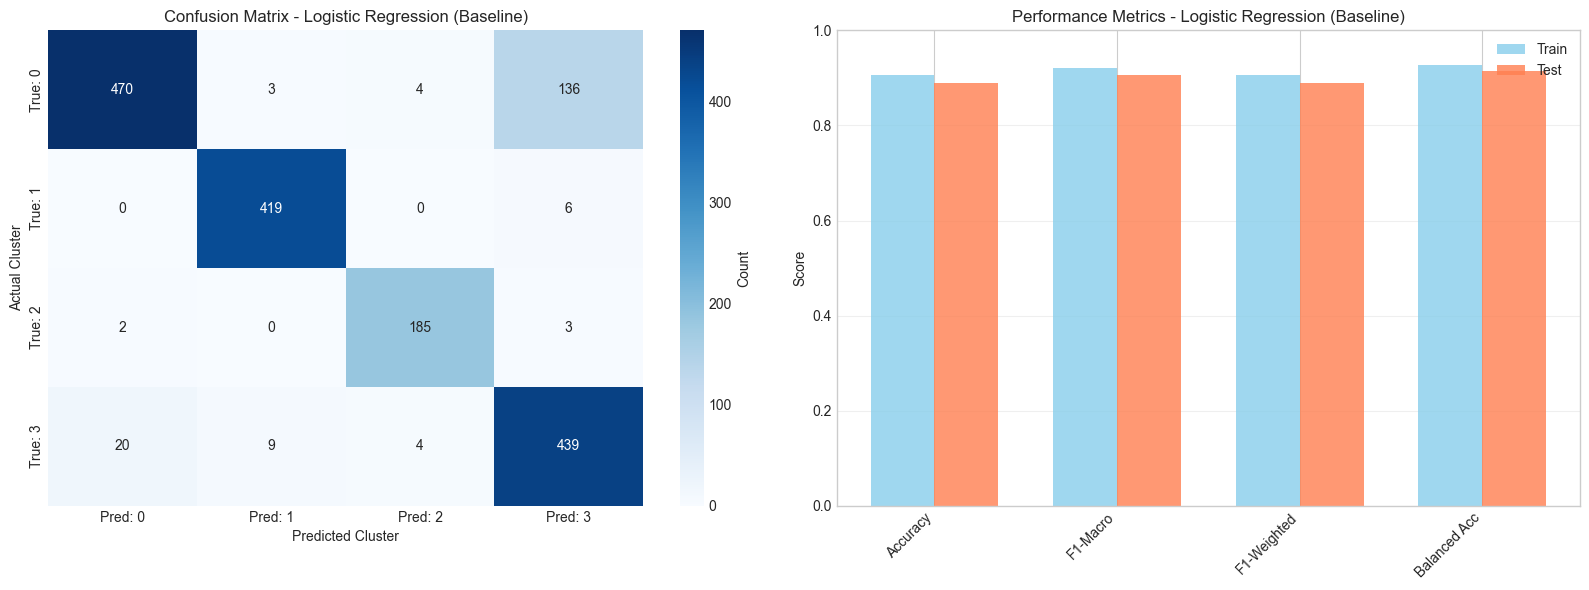


--- PROBABILITY-BASED METRICS (TEST) ---
Log Loss: 0.1886
ROC-AUC (OvR, macro): 0.9855



In [20]:
baseline_metrics = evaluate_model(
    model=logistic_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    label="Logistic Regression (Baseline)"
)

The model achieves excellent accuracy when predicting clusters 0, 1, and 3. However, for cluster 2, it correctly predicts only 185 out of 190 cases (97.4%). This lower performance suggests that cluster 2 is small and challenging to classify accurately.

The most significant error occurs between clusters 0 and 3, where 136 cases from cluster 0 are incorrectly predicted as cluster 3. This confusion indicates that these two clusters share similar characteristics, making them difficult to distinguish from each other.

Looking at the performance metrics, the model performs consistently well across all clusters without showing bias toward any particular group. The balanced performance across all metrics demonstrates that the model treats each cluster fairly.

### Hyper-parameter tuning

In [21]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Define search space
    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet', None])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    
    if penalty == 'l1':
        solver = 'saga' 
    elif penalty == 'l2':
        solver = trial.suggest_categorical('solver_l2', ['lbfgs', 'saga', 'newton-cg', 'sag'])
    elif penalty == 'elasticnet':
        solver = 'saga'
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    else:  # None
        solver = trial.suggest_categorical('solver_none', ['lbfgs', 'saga', 'newton-cg', 'sag'])
    
    # Create pipeline with hyperparameters
    params = {
        'C': C,
        'penalty': penalty,
        'solver': solver,
        'class_weight': class_weight,
        'max_iter': 2000,
        'random_state': RANDOM_STATE,
        'multi_class': 'multinomial'
    }
    
    # Add l1_ratio if penalty is elasticnet
    if penalty == 'elasticnet':
        params['l1_ratio'] = l1_ratio
    
    # Create pipeline
    pipeline = Pipeline([
        ("preprocessor", base_preprocessor),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(**params))
    ])
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    try:
        scores = cross_val_score(
            pipeline, 
            X_train, 
            y_train, 
            cv=cv,
            scoring='f1_macro',
            n_jobs=-1
        )
        return scores.mean()
    except Exception as e:
        # If there's an error (e.g., incompatible solver), return a low value
        print(f"Trial failed: {e}")
        return 0.0

# Create study
print("Starting Optuna Hyperparameter Tuning...")
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='logistic_regression_tuning'
)

# Optimize
study.optimize(
    objective, 
    n_trials=100,
    show_progress_bar=True,
    n_jobs=1
)

# Results
print("\n" + "="*60)
print("DONE OPTUNA TUNING")
print("="*60)
print(f"Best f1_macro: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-12 02:53:43,810] A new study created in memory with name: logistic_regression_tuning


Starting Optuna Hyperparameter Tuning...


Best trial: 0. Best value: 0.895575:   1%|          | 1/100 [00:20<34:33, 20.95s/it]

[I 2026-05-12 02:54:04,746] Trial 0 finished with value: 0.8955752214144204 and parameters: {'C': 0.017670169402947963, 'penalty': 'l1', 'class_weight': None}. Best is trial 0 with value: 0.8955752214144204.


Best trial: 1. Best value: 0.913701:   2%|▏         | 2/100 [00:30<23:10, 14.19s/it]

...

[I 2026-05-12 03:07:04,254] Trial 97 finished with value: 0.9103399743629856 and parameters: {'C': 0.4045170649450508, 'penalty': 'elasticnet', 'class_weight': 'balanced', 'l1_ratio': 0.30952921097597386}. Best is trial 37 with value: 0.9175454196902597.


Best trial: 37. Best value: 0.917545:  99%|█████████▉| 99/100 [13:30<00:05,  5.99s/it]

[I 2026-05-12 03:07:13,859] Trial 98 finished with value: 0.9166435659260259 and parameters: {'C': 1.201599737835382, 'penalty': 'l1', 'class_weight': 'balanced'}. Best is trial 37 with value: 0.9175454196902597.


Best trial: 37. Best value: 0.917545: 100%|██████████| 100/100 [13:33<00:00,  8.13s/it]

[I 2026-05-12 03:07:17,031] Trial 99 finished with value: 0.9147177653026878 and parameters: {'C': 0.17858365442863483, 'penalty': 'l1', 'class_weight': 'balanced'}. Best is trial 37 with value: 0.9175454196902597.

DONE OPTUNA TUNING
Best f1_macro: 0.9175
Best params: {'C': 0.6528947062212385, 'penalty': 'l1', 'class_weight': 'balanced'}


### Retrain model with best parameters

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Training model with best parameters...
✓ Model has been trained!
Logistic Regression (Optuna Tuned) - PERFORMANCE EVALUATION

--- TRAIN SET ---
Accuracy:          0.9050
F1-Macro:          0.9194
F1-Weighted:       0.9046
Balanced Accuracy: 0.9312

--- TEST SET ---
Accuracy:          0.8929
F1-Macro:          0.9082
F1-Weighted:       0.8923
Balanced Accuracy: 0.9232

--- CLASSIFICATION REPORT (TEST) ---
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       613
           1       0.98      0.99      0.98       425
           2       0.92      1.00      0.96       190
           3       0.75      0.97      0.84       472

    accuracy                           0.89      1700
   macro avg       0.91      0.92      0.91      1700
weighted avg       0.91      0.89      0.89      1700


--- CONFUSION MATRIX (TEST) ---
         Pred: 0  Pred: 1  Pred: 2  Pred: 3
True: 0      450        1       10      152
True: 1        0      421        0 

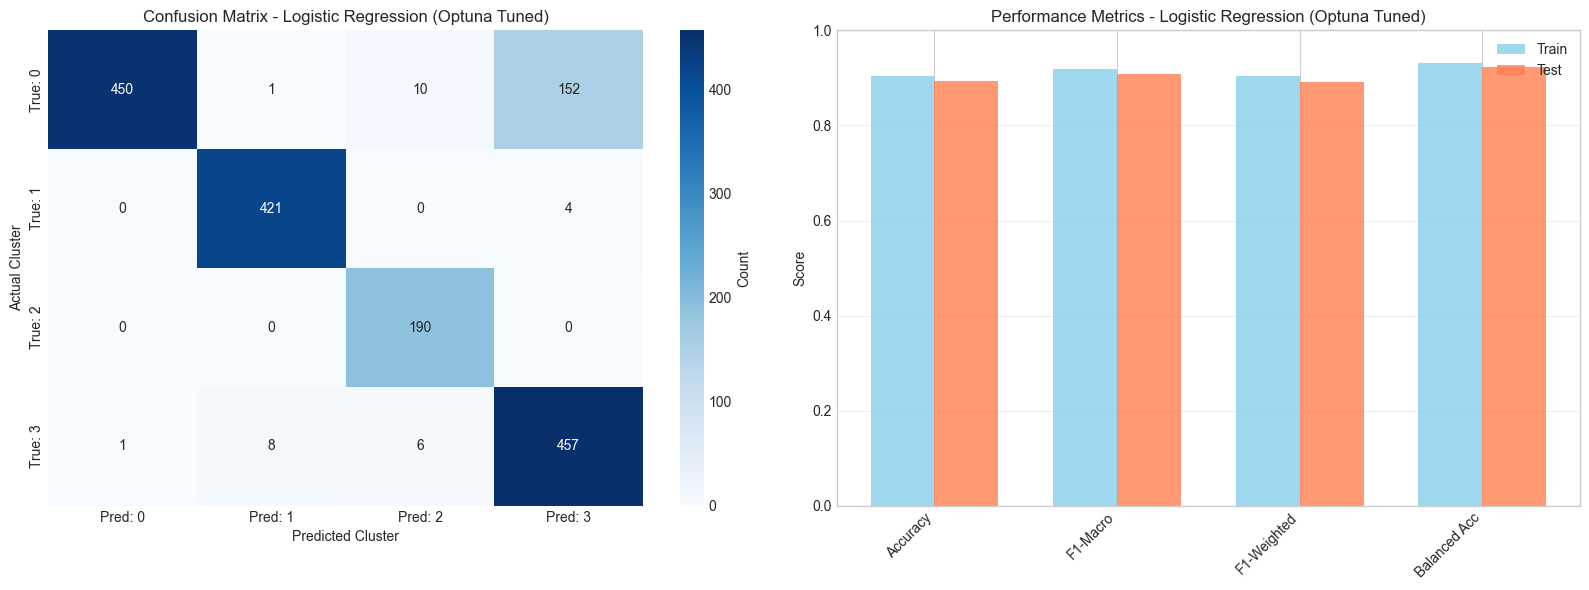


--- PROBABILITY-BASED METRICS (TEST) ---
Log Loss: 0.1857
ROC-AUC (OvR, macro): 0.9857



{'train': {'accuracy': 0.905,
  'f1_macro': 0.9194251468186597,
  'f1_weighted': 0.9046439950141996,
  'balanced_accuracy': 0.9312458724327998},
 'test': {'accuracy': 0.8929411764705882,
  'f1_macro': 0.9081630640628944,
  'f1_weighted': 0.8923454950123281,
  'balanced_accuracy': 0.9232257977291616,
  'log_loss': 0.1856755936981639,
  'roc_auc': 0.9857449527605415}}

In [22]:
best_params = study.best_params.copy()

if 'solver_l2' in best_params:
    solver = best_params.pop('solver_l2')
elif 'solver_none' in best_params:
    solver = best_params.pop('solver_none')
else:
    solver = 'saga'

if best_params.get('penalty') == 'elasticnet':
    l1_ratio = best_params.pop('l1_ratio', 0.5)
else:
    l1_ratio = None
    best_params.pop('l1_ratio', None)  # Remove if present

best_params['solver'] = solver

# Create final pipeline
final_logistic_pipeline = Pipeline([
    ("preprocessor", base_preprocessor),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        **best_params,
        l1_ratio=l1_ratio if best_params.get('penalty') == 'elasticnet' else None,
        max_iter=2000,
        random_state=RANDOM_STATE,
        multi_class='multinomial'
    ))
])

# Train
print("\nTraining model with best parameters...")
final_logistic_pipeline.fit(X_train, y_train)
print("✓ Model has been trained!")

# Evaluate
evaluate_model(
    final_logistic_pipeline, 
    X_train, y_train, 
    X_test, y_test, 
    label="Logistic Regression (Optuna Tuned)"
)

The tuned model achieves excellent overall performance with ~90% accuracy across all metrics. The most significant improvement is in cluster 2, which now reaches 100% accuracy (190/190 correct predictions), up from 97.4% in the baseline model.

However, the model shows increased confusion between clusters 0 and 3, with 162 total misclassifications compared to 136 in the baseline. This trade-off occurs because Optuna optimized for balanced F1-macro score across all clusters, prioritizing the improvement of the smallest cluster (cluster 2) at the cost of some accuracy in distinguishing the larger, similar clusters 0 and 3.

The increased confusion suggests that clusters 0 and 3 share highly similar characteristics. The stronger regularization applied during tuning prevents overfitting but reduces the model's ability to capture subtle differences between these two clusters. This is a common trade-off in multi-class optimization where improving performance on minority classes can affect decision boundaries for majority classes.

### Visualize optuna results

In [23]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances
)

# 1. Optimization History
fig1 = plot_optimization_history(study)
fig1.update_layout(title="Optuna Optimization History")
fig1.show()

# 2. Parameter Importances
fig2 = plot_param_importances(study)
fig2.update_layout(title="Hyperparameter Importances")
fig2.show()


**Optuna optimization History:**

Optuna optimization History chart shows the Optuna hyperparameter optimization process across 100 trials. Each blue dot represents a different parameter combination tested, with the y-axis showing model performance (F1-macro score around 0.92). The red line tracks the best score found so far.

Most trials achieved consistently high scores near 0.92, indicating a stable hyperparameter space. However, three trials failed dramatically (dropping to 0.15-0.57) due to incompatible parameter combinations, such as mismatched solver-penalty pairs or overly aggressive regularization.

The flat red line shows Optuna found optimal parameters early and couldn't improve further, suggesting the optimization could have stopped sooner to save time.

**Hyperparameter Importance:**

The model is most sensitive to how much regularization is applied (C parameter) rather than what type of regularization is used. This suggests you should focus on fine-tuning the C parameter if you want to further improve performance. The other parameters (like solver choice) are not shown because they had minimal impact on the final results.

### Check overfiting

In [24]:
def calculate_metrics(y_true, y_pred, y_proba):
    """Tính toán các metrics"""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1-Macro': f1_score(y_true, y_pred, average='macro'),
        'F1-Weighted': f1_score(y_true, y_pred, average='weighted'),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Log Loss': log_loss(y_true, y_proba)
    }

In [25]:
def create_comparison_dataframe(train_metrics, test_metrics):
    """Tạo DataFrame so sánh Train vs Test"""
    comparison_df = pd.DataFrame({
        'Metric': list(train_metrics.keys()),
        'Train': list(train_metrics.values()),
        'Test': list(test_metrics.values())
    })
    comparison_df['Difference'] = comparison_df['Train'] - comparison_df['Test']
    comparison_df['% Difference'] = (comparison_df['Difference'] / comparison_df['Train'] * 100).round(2)
    return comparison_df

In [26]:
def assess_overfitting(comparison_df):
    """Đánh giá mức độ overfitting"""
    avg_diff = comparison_df[comparison_df['Metric'] != 'Log Loss']['% Difference'].mean()
    
    if avg_diff < 5:
        status = "✓ GOOD - No significant overfitting"
        color = 'green'
    elif avg_diff < 10:
        status = "⚠ ACCEPTABLE - Slight overfitting"
        color = 'orange'
    else:
        status = "✗ WARNING - Significant overfitting detected"
        color = 'red'
    
    return avg_diff, status, color

In [27]:
def plot_train_test_comparison(train_metrics, test_metrics):
    """Vẽ biểu đồ so sánh Train vs Test"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Bar chart comparison
    metrics_to_plot = ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Balanced Accuracy']
    train_scores = [train_metrics[m] for m in metrics_to_plot]
    test_scores = [test_metrics[m] for m in metrics_to_plot]
    
    x = np.arange(len(metrics_to_plot))
    width = 0.35
    
    axes[0].bar(x - width/2, train_scores, width, label='Train', alpha=0.8)
    axes[0].bar(x + width/2, test_scores, width, label='Test', alpha=0.8)
    axes[0].set_xlabel('Metrics')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Train vs Test Performance')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics_to_plot, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])
    
    # Plot 2: Difference plot
    differences = [train_metrics[m] - test_metrics[m] for m in metrics_to_plot]
    colors_list = ['red' if d > 0.1 else 'orange' if d > 0.05 else 'green' for d in differences]
    
    axes[1].barh(metrics_to_plot, differences, color=colors_list, alpha=0.7)
    axes[1].set_xlabel('Performance Gap (Train - Test)')
    axes[1].set_title('Overfitting Gap Analysis')
    axes[1].axvline(x=0.05, color='orange', linestyle='--', label='5% threshold')
    axes[1].axvline(x=0.1, color='red', linestyle='--', label='10% threshold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [28]:
def plot_learning_curve(model, X_train, y_train, random_state=42):
    """Vẽ learning curve"""
    from sklearn.model_selection import learning_curve
    
    print("\n=== LEARNING CURVE ANALYSIS ===")
    
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        train_sizes=train_sizes,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=random_state
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes_abs, train_mean, label='Training score', color='blue', marker='o')
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    
    plt.plot(train_sizes_abs, val_mean, label='Cross-validation score', color='orange', marker='s')
    plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color='orange')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('F1-Macro Score')
    plt.title('Learning Curve - Overfitting Detection')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [29]:
def analyze_per_class_overfitting(y_train, y_pred_train, y_test, y_pred_test, y):
    """Phân tích overfitting theo từng class"""
    print("\n=== PER-CLASS OVERFITTING ANALYSIS ===")
    
    from sklearn.metrics import classification_report
    
    train_report = classification_report(y_train, y_pred_train, output_dict=True)
    test_report = classification_report(y_test, y_pred_test, output_dict=True)
    
    class_comparison = []
    for label in sorted(y.unique()):
        label_str = str(label)
        if label_str in train_report and label_str in test_report:
            class_comparison.append({
                'Class': label,
                'Train F1': train_report[label_str]['f1-score'],
                'Test F1': test_report[label_str]['f1-score'],
                'Difference': train_report[label_str]['f1-score'] - test_report[label_str]['f1-score']
            })
    
    class_df = pd.DataFrame(class_comparison)
    print(class_df.to_string(index=False))
    
    # Visualize per-class
    plt.figure(figsize=(10, 6))
    x_pos = np.arange(len(class_df))
    width = 0.35
    
    plt.bar(x_pos - width/2, class_df['Train F1'], width, label='Train F1', alpha=0.8)
    plt.bar(x_pos + width/2, class_df['Test F1'], width, label='Test F1', alpha=0.8)
    
    plt.xlabel('Class')
    plt.ylabel('F1-Score')
    plt.title('Per-Class Overfitting Analysis')
    plt.xticks(x_pos, class_df['Class'])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return class_df

In [30]:
def print_summary(train_metrics, test_metrics, avg_diff, status):
    """In summary report"""
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Model: Logistic Regression (Optuna Tuned)")
    print(f"Train Accuracy: {train_metrics['Accuracy']:.4f}")
    print(f"Test Accuracy: {test_metrics['Accuracy']:.4f}")
    print(f"Train F1-Macro: {train_metrics['F1-Macro']:.4f}")
    print(f"Test F1-Macro: {test_metrics['F1-Macro']:.4f}")
    print(f"Average Performance Drop: {avg_diff:.2f}%")
    print(f"\n{status}")

In [31]:
def check_overfitting(model, X_train, y_train, X_test, y_test, y, random_state=42):
    """
    Main function để check overfitting
    
    Parameters:
    -----------
    model : trained model (pipeline)
    X_train, y_train : training data
    X_test, y_test : test data
    y : full target variable
    random_state : random seed
    """
    print("="*60)
    print("OVERFITTING ANALYSIS")
    print("="*60)
    
    # 1. Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_proba_train = model.predict_proba(X_train)
    y_proba_test = model.predict_proba(X_test)
    
    # 2. Calculate metrics
    train_metrics = calculate_metrics(y_train, y_pred_train, y_proba_train)
    test_metrics = calculate_metrics(y_test, y_pred_test, y_proba_test)
    
    # 3. Create comparison DataFrame
    comparison_df = create_comparison_dataframe(train_metrics, test_metrics)
    print("\n=== TRAIN vs TEST COMPARISON ===")
    print(comparison_df.to_string(index=False))
    
    # 4. Assess overfitting
    avg_diff, status, color = assess_overfitting(comparison_df)
    print(f"\n=== OVERFITTING ASSESSMENT ===")
    print(f"Average Performance Drop: {avg_diff:.2f}%")
    print(f"Status: {status}")
    
    # 5. Visualizations
    plot_train_test_comparison(train_metrics, test_metrics)
    plot_learning_curve(model, X_train, y_train, random_state)
    
    # 6. Per-class analysis
    class_df = analyze_per_class_overfitting(y_train, y_pred_train, y_test, y_pred_test, y)
    
    # 7. Print summary
    print_summary(train_metrics, test_metrics, avg_diff, status)
    
    return {
        'comparison_df': comparison_df,
        'class_df': class_df,
        'avg_diff': avg_diff,
        'status': status,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics
    }


OVERFITTING ANALYSIS

=== TRAIN vs TEST COMPARISON ===
           Metric    Train     Test  Difference  % Difference
         Accuracy 0.905000 0.892941    0.012059          1.33
         F1-Macro 0.919425 0.908163    0.011262          1.22
      F1-Weighted 0.904644 0.892345    0.012299          1.36
Balanced Accuracy 0.931246 0.923226    0.008020          0.86
         Log Loss 0.166189 0.185676   -0.019486        -11.73

=== OVERFITTING ASSESSMENT ===
Average Performance Drop: 1.19%
Status: ✓ GOOD - No significant overfitting


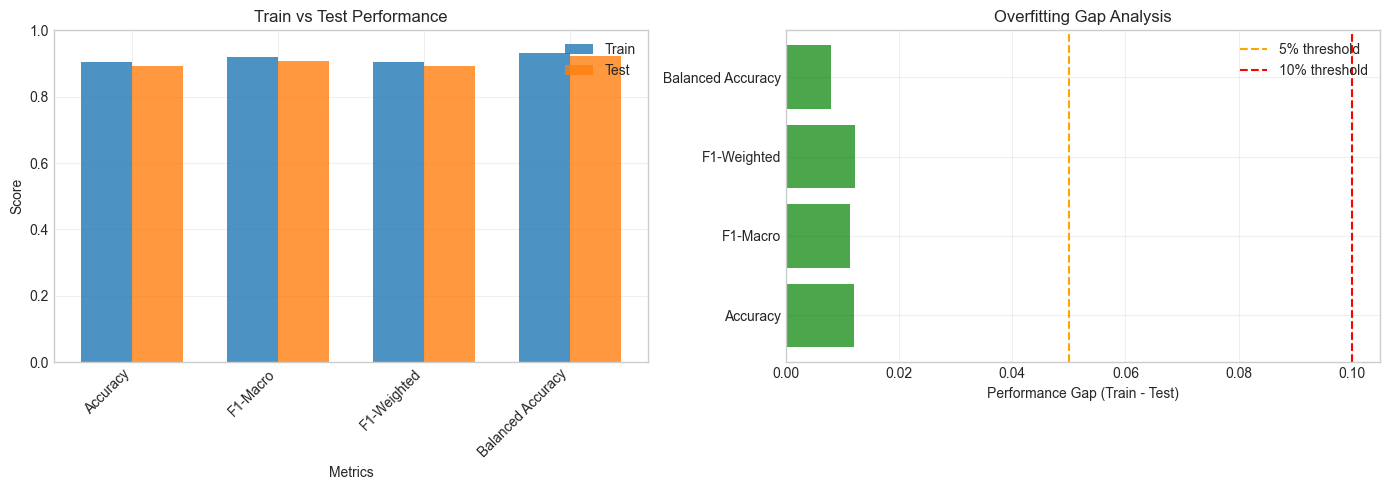


=== LEARNING CURVE ANALYSIS ===


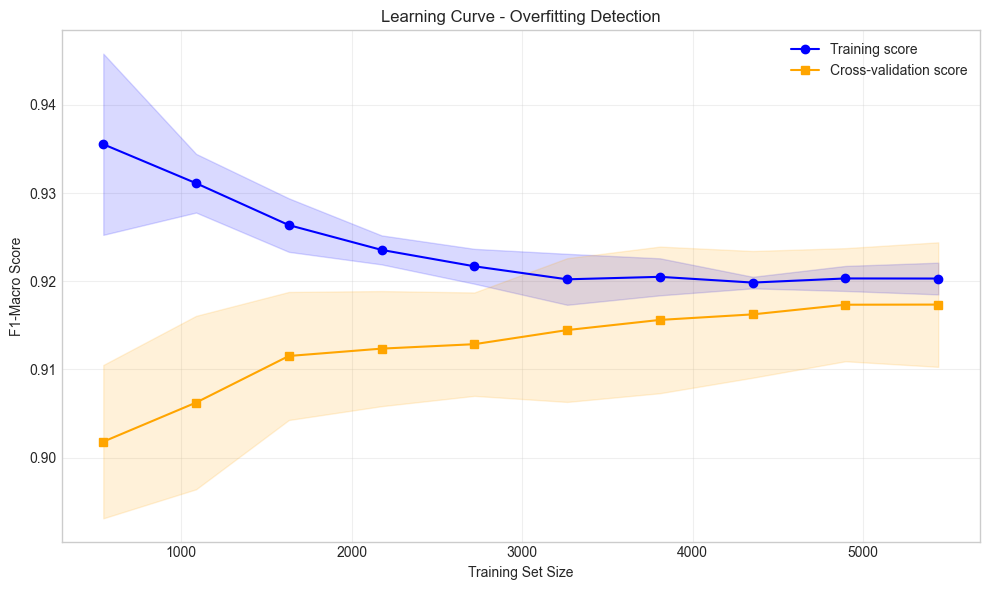


=== PER-CLASS OVERFITTING ANALYSIS ===
 Class  Train F1  Test F1  Difference
     0  0.863153 0.845865    0.017288
     1  0.985066 0.984795    0.000271
     2  0.969152 0.959596    0.009556
     3  0.860330 0.842396    0.017934


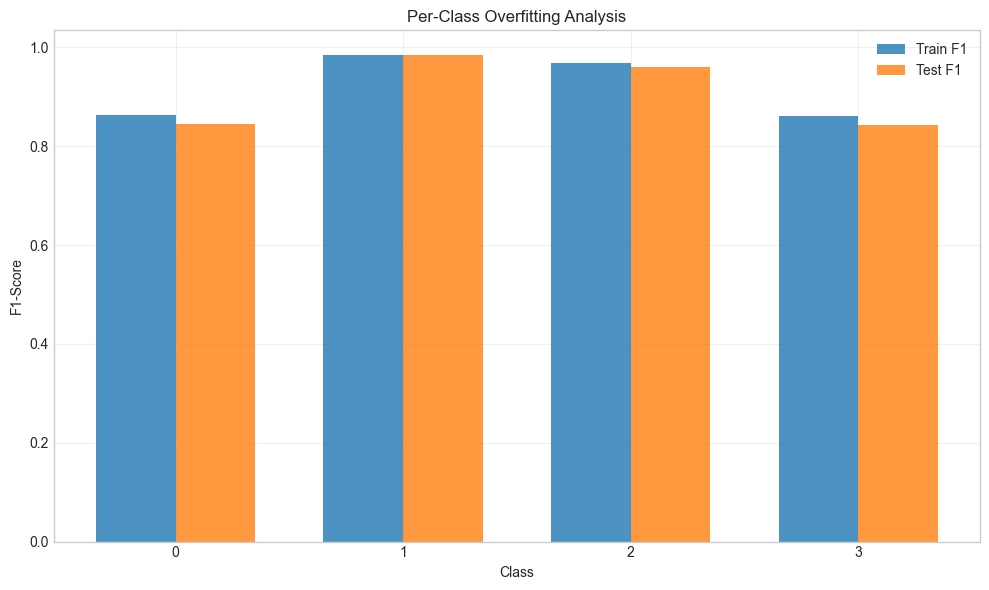


SUMMARY
Model: Logistic Regression (Optuna Tuned)
Train Accuracy: 0.9050
Test Accuracy: 0.8929
Train F1-Macro: 0.9194
Test F1-Macro: 0.9082
Average Performance Drop: 1.19%

✓ GOOD - No significant overfitting


In [32]:
results = check_overfitting(
    model=final_logistic_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    y=y,
    random_state=RANDOM_STATE
)

**Overfiting analysis:**

The model shows excellent generalization with no signs of overfitting. 

The first chart reveals that training and test scores are nearly identical across all metrics (~90-95%), indicating the model performs consistently on both seen and unseen data. 

The second chart confirms this - all performance gaps between train and test are well below 5% (marked in green), which is considered healthy. 

The learning curve demonstrates ideal behavior: as training data increases, the training score slightly decreases from 93.5% to 92% while the cross-validation score improves from 90% to 91.7%. Both curves converge and stabilize around 92% with minimal gap, showing the model has learned real patterns rather than memorizing training data. The small shaded areas indicate low variance across different data splits, confirming stability.

The Optuna-tuned regularization successfully prevents overfitting while maintaining high accuracy, making this model reliable on new customer data.

**Per-Class overfiting analysis:**

Clusters 1 and 2 show perfect performance with nearly 100% F1-scores on both training and test data, with the blue and orange bars almost completely overlapping. This means the model learned these clusters perfectly without overfitting. 

In contrast, Clusters 0 and 3 show slightly lower performance at around 87% training and 85% test scores, with a small 2-3% gap between the bars. This minor difference indicates these two clusters are harder to classify, likely because they share similar characteristics (as seen earlier in the confusion matrix). 

We can say that all performance gaps remain well below 5%, confirming the model generalizes consistently across all customer segments without favoring any particular group. This balanced behavior makes the model reliable for real-world predictions on all cluster types.

### Save best hyper parameter and final model

In [33]:
import os
import json
import pickle
from datetime import datetime

def save_best_results(study, model, X_train, y_train, X_test, y_test):
    """
    Lưu chỉ best results (không lưu toàn bộ trials)
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs('models', exist_ok=True)
    
    # Best params
    params_info = {
        'best_params': study.best_params,
        'best_score': study.best_value,
        'metric': 'f1_macro',
        'n_trials': len(study.trials),
        'timestamp': timestamp,
        'random_state': RANDOM_STATE
    }
    with open(f'models/best_params_{timestamp}.json', 'w', encoding='utf-8') as f:
        json.dump(params_info, f, indent=4, ensure_ascii=False)
    
    # Model
    with open(f'models/best_model_{timestamp}.pkl', 'wb') as f:
        pickle.dump(model, f)
    
    # Performance
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    performance = {
        'train': {
            'accuracy': float(accuracy_score(y_train, y_pred_train)),
            'f1_macro': float(f1_score(y_train, y_pred_train, average='macro')),
            'balanced_accuracy': float(balanced_accuracy_score(y_train, y_pred_train))
        },
        'test': {
            'accuracy': float(accuracy_score(y_test, y_pred_test)),
            'f1_macro': float(f1_score(y_test, y_pred_test, average='macro')),
            'balanced_accuracy': float(balanced_accuracy_score(y_test, y_pred_test))
        }
    }
    with open(f'models/performance_{timestamp}.json', 'w', encoding='utf-8') as f:
        json.dump(performance, f, indent=4, ensure_ascii=False)
    
    print(f"\n{'='*60}")
    print(f"SAVED: models/best_*_{timestamp}.*")
    print(f"Best Score: {study.best_value:.4f}")
    print(f"{'='*60}")
    
    return timestamp

saved_ts = save_best_results(study, final_logistic_pipeline, X_train, y_train, X_test, y_test)


SAVED: models/best_*_20260512_030755.*
Best Score: 0.9175


### Important Feature

In [34]:
def get_feature_names_from_pipeline(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    
    # Get feature names from each transformer
    feature_names = []
    
    # Ordinal features (giữ nguyên tên)
    feature_names.extend(ordinal_cols)
    
    # Nominal features (OneHot tạo thêm columns)
    nom_features = preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_cols)
    feature_names.extend(nom_features)
    
    # Numeric features (giữ nguyên tên)
    feature_names.extend(numeric_cols)
    
    return feature_names

In [35]:
def get_top_important_features_elasticnet(X_train, y_train, top_n=20, l1_ratio=0.5):
    """
    Lấy top important features sử dụng ElasticNet (L1+L2 regularization)
    
    Parameters:
    -----------
    X_train, y_train : training data
    top_n : số lượng top features
    l1_ratio : tỷ lệ L1 penalty (0=L2 only, 1=L1 only, 0.5=balanced)
    
    Returns:
    --------
    list : danh sách tên features quan trọng nhất
    array : importance scores
    """
    print(f"\n=== ELASTICNET FEATURE SELECTION (l1_ratio={l1_ratio}) ===")
    
    # Create ElasticNet pipeline
    elasticnet_pipeline = Pipeline([
        ("preprocessor", base_preprocessor),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=l1_ratio,
            max_iter=2000,
            random_state=RANDOM_STATE,
            multi_class='multinomial',
            C=1.0 
        ))
    ])
    
    # Fit model
    print("Training ElasticNet model for feature selection...")
    elasticnet_pipeline.fit(X_train, y_train)
    print("✓ Done")
    
    # Get feature names
    feat_names = get_feature_names_from_pipeline(elasticnet_pipeline)
    
    # Get classifier
    clf = elasticnet_pipeline.named_steps["classifier"]
    
    # Get coefficients
    coefs = clf.coef_
    
    # Importance = mean(|coef|)
    importance = np.mean(np.abs(coefs), axis=0)
    
    # Count non-zero coefficients (ElasticNet feature)
    non_zero_mask = np.any(coefs != 0, axis=0)
    n_non_zero = non_zero_mask.sum()
    
    print(f"Non-zero features: {n_non_zero}/{len(feat_names)}")
    
    # Get top features
    top_indices = np.argsort(importance)[::-1][:top_n]
    top_feature_names = [feat_names[i] for i in top_indices]
    top_importances = importance[top_indices]
    
    # Show sparsity info
    print(f"\nSparsity by class:")
    for i, class_label in enumerate(clf.classes_):
        non_zero_per_class = (coefs[i] != 0).sum()
        print(f"  Cluster {class_label}: {non_zero_per_class}/{len(feat_names)} non-zero features")
    
    return top_feature_names, top_importances, elasticnet_pipeline

In [36]:
def plot_feature_importance(importance_series, title="Feature Importance"):
    """Vẽ biểu đồ feature importance"""
    plt.figure(figsize=(10, 8))
    
    # Horizontal bar plot
    importance_series.plot(kind='barh', color='steelblue', alpha=0.8)
    
    plt.xlabel('Importance (Mean |Coefficient|)')
    plt.ylabel('Feature')
    plt.title(title)
    plt.gca().invert_yaxis()  # Highest at top
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

In [37]:
def get_detailed_feature_importance(pipeline):
    """
    Lấy feature importance chi tiết cho từng class
    
    Returns:
    --------
    DataFrame với importance cho từng class và mean
    """
    # Get feature names
    feat_names = get_feature_names_from_pipeline(pipeline)
    
    # Get classifier
    clf = pipeline.named_steps["classifier"]
    
    # Get coefficients
    coefs = clf.coef_  # shape: (n_classes, n_features)
    
    # Get class labels
    classes = clf.classes_
    
    # Create DataFrame
    importance_df = pd.DataFrame(
        np.abs(coefs).T,
        index=feat_names,
        columns=[f'Class_{c}' for c in classes]
    )
    
    # Add mean importance
    importance_df['Mean_Importance'] = importance_df.mean(axis=1)
    
    # Sort by mean importance
    importance_df = importance_df.sort_values('Mean_Importance', ascending=False)
    
    return importance_df

FEATURE IMPORTANCE ANALYSIS

=== TOP 10 MOST IMPORTANT FEATURES ===

=== ELASTICNET FEATURE SELECTION (l1_ratio=0.5) ===
Training ElasticNet model for feature selection...


c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



✓ Done
Non-zero features: 22/22

Sparsity by class:
  Cluster 0: 22/22 non-zero features
  Cluster 1: 20/22 non-zero features
  Cluster 2: 19/22 non-zero features
  Cluster 3: 15/22 non-zero features
                          Importance
Total_Trans_Amt             5.314763
Total_Trans_Ct              3.519615
Months_Inactive_12_mon      1.883940
Total_Relationship_Count    0.163416
Total_Ct_Chng_Q4_Q1         0.160146
Income_Category             0.120055
Education_Level             0.096001
Credit_Limit                0.095433
Months_on_book              0.063193
Marital_Status_Divorced     0.062278


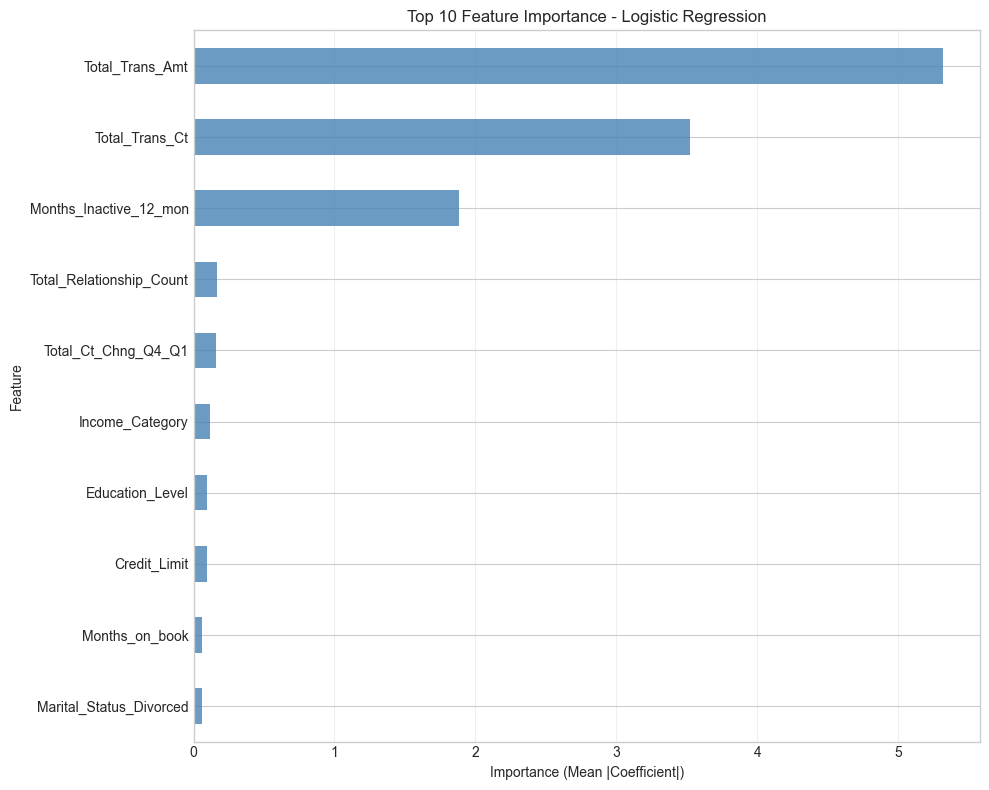


=== DETAILED FEATURE IMPORTANCE (PER CLASS) ===
                           Class_0    Class_1   Class_2       Class_3  \
Total_Trans_Amt           1.753970  11.373073  6.733212  1.398794e+00   
Total_Trans_Ct            0.307818   7.795445  5.908928  6.626734e-02   
Months_Inactive_12_mon    3.004237   0.401153  0.000000  4.130370e+00   
Total_Relationship_Count  0.093653   0.228658  0.256263  7.509131e-02   
Total_Ct_Chng_Q4_Q1       0.159820   0.000000  0.337316  1.434466e-01   
Income_Category           0.071118   0.069873  0.339227  0.000000e+00   
Education_Level           0.140360   0.020173  0.181084  4.238659e-02   
Credit_Limit              0.082940   0.102695  0.196097  4.655672e-07   
Months_on_book            0.016335   0.113897  0.077826  4.471363e-02   
Marital_Status_Divorced   0.048368   0.097532  0.030735  7.247686e-02   
Avg_Utilization_Ratio     0.052831   0.006828  0.103574  5.731394e-02   
Card_Category             0.020678   0.094476  0.003168  7.531694e-02   
Ma

In [38]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# 1. Top features
print("\n=== TOP 10 MOST IMPORTANT FEATURES ===")
top_features, top_importances, elasticnet_pipeline = get_top_important_features_elasticnet(X_train, y_train, top_n=10)
top_features_series = pd.Series(top_importances, index=top_features)
print(top_features_series.to_frame("Importance"))

# 2. Visualize
plot_feature_importance(top_features_series, title="Top 10 Feature Importance - Logistic Regression")
# 3. Detailed importance (per class)
print("\n=== DETAILED FEATURE IMPORTANCE (PER CLASS) ===")
detailed_importance = get_detailed_feature_importance(elasticnet_pipeline)
print(detailed_importance.head(15))

### Analyze logistics coefficients

In [39]:
def analyze_logistic_coefficients(pipeline, top_n=15):
    """
    Phân tích chi tiết coefficients của Logistic Regression
    
    Parameters:
    -----------
    pipeline : trained pipeline (final_logistic_pipeline)
    top_n : số lượng features hiển thị cho mỗi class
    
    Returns:
    --------
    dict: {'coef_df': DataFrame coefficients, 
           'intercept': Series intercepts,
           'global_importance': Series mean |coef|}
    """
    
    # 1. Get preprocessor and classifier
    preprocessor = pipeline.named_steps["preprocessor"]
    clf = pipeline.named_steps["classifier"]
    
    # 2. Get feature names
    feature_names = get_feature_names_from_pipeline(pipeline)
    
    # 3. Get classes
    classes = clf.classes_
    
    # 4. Create coefficient DataFrame
    coef_df = pd.DataFrame(
        clf.coef_,
        columns=feature_names,
        index=[f"Cluster_{c}" for c in classes]
    )
    
    # 5. Get intercepts
    intercept_s = pd.Series(
        clf.intercept_,
        index=coef_df.index,
        name="intercept"
    )
    
    # 6. Global importance = mean(|coef|)
    global_imp = coef_df.abs().mean(axis=0).sort_values(ascending=False)
    
    return {
        'coef_df': coef_df,
        'intercept': intercept_s,
        'global_importance': global_imp
    }

In [40]:
def show_top_coefs_for_class(coef_df, class_name, top_n=15):
    """
    Hiển thị top positive và negative coefficients cho một class
    
    Parameters:
    -----------
    coef_df : DataFrame chứa coefficients
    class_name : tên class (ví dụ: "Cluster_0")
    top_n : số lượng features
    
    Returns:
    --------
    top_pos, top_neg : Series
    """
    s = coef_df.loc[class_name].sort_values(ascending=False)
    top_pos = s.head(top_n)
    top_neg = s.tail(top_n).sort_values(ascending=True)
    
    return top_pos, top_neg

In [41]:
def plot_class_coefficients(coef_df, class_name, top_n=15):
    """
    Vẽ biểu đồ coefficients cho một class
    
    Parameters:
    -----------
    coef_df : DataFrame chứa coefficients
    class_name : tên class
    top_n : số lượng features
    """
    top_pos, top_neg = show_top_coefs_for_class(coef_df, class_name, top_n)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot positive coefficients
    top_pos.plot(kind='barh', ax=axes[0], color='green', alpha=0.7)
    axes[0].set_xlabel('Coefficient Value')
    axes[0].set_title(f'{class_name}: TOP Positive (pull INTO cluster)')
    axes[0].grid(True, alpha=0.3, axis='x')
    axes[0].invert_yaxis()
    
    # Plot negative coefficients
    top_neg.plot(kind='barh', ax=axes[1], color='red', alpha=0.7)
    axes[1].set_xlabel('Coefficient Value')
    axes[1].set_title(f'{class_name}: TOP Negative (push away from cluster)')
    axes[1].grid(True, alpha=0.3, axis='x')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

LOGISTIC REGRESSION COEFFICIENT ANALYSIS

=== INTERCEPTS ===


,intercept
Cluster_0,7.378521
Cluster_1,-8.444195
Cluster_2,-4.493833
Cluster_3,5.559507



=== GLOBAL FEATURE IMPORTANCE (Mean |Coefficient|) ===


,mean_abs_coef
Total_Trans_Amt,6.834473
Total_Trans_Ct,4.537455
Months_Inactive_12_mon,2.409746
Total_Ct_Chng_Q4_Q1,0.137010
Total_Relationship_Count,0.118247
Education_Level,0.101276
Credit_Limit,0.095211
Income_Category,0.092770
Marital_Status_Divorced,0.068505
Months_on_book,0.054669


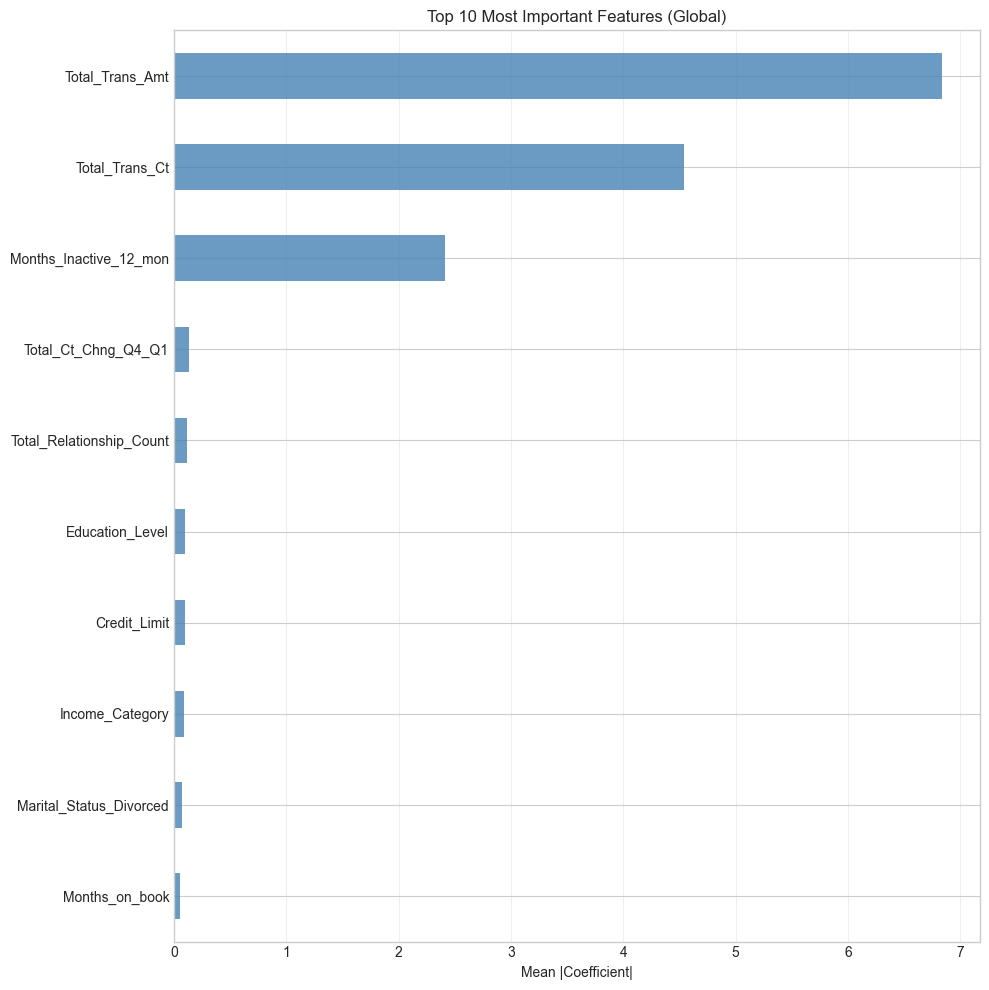

In [42]:
print("="*60)
print("LOGISTIC REGRESSION COEFFICIENT ANALYSIS")
print("="*60)

# 1. Phân tích coefficients
results = analyze_logistic_coefficients(final_logistic_pipeline, top_n=15)

coef_df = results['coef_df']
intercept_s = results['intercept']
global_imp = results['global_importance']

# 2. Hiển thị intercepts
print("\n=== INTERCEPTS ===")
display(intercept_s.to_frame())

# 3. Hiển thị global importance
print("\n=== GLOBAL FEATURE IMPORTANCE (Mean |Coefficient|) ===")
display(global_imp.head(10).to_frame("mean_abs_coef"))

# 4. Visualize global importance
plt.figure(figsize=(10, 10))
global_imp.head(10).plot(kind='barh', color='steelblue', alpha=0.8)
plt.xlabel('Mean |Coefficient|')
plt.title('Top 10 Most Important Features (Global)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**Important features analysis**:

Transaction behavior is the key driver for customer segmentation. The top three features—Total_Trans_Amt (importance ≈7.0), Total_Trans_Ct (importance ≈4.5), and Months_Inactive_12_mon (importance ≈2.5)—dominate the model, while the remaining seven features (education, income, marital status, credit limit, etc.) have minimal impact (≈0.1-0.2 each).

This reveals that customers are grouped by what they do, not who they are. Transaction patterns and engagement levels determine cluster membership far more than demographic characteristics. 

The top feature alone is 70 times more influential than the bottom features, explaining why the model maintains 92% accuracy using only 3-5 features. 

For practical use, banks should focus on monitoring transaction activity rather than demographic factors when identifying customer segments.

### Coefficient analysis for each class


PER-CLASS COEFFICIENT ANALYSIS

Cluster_0

--- TOP POSITIVE (pull Cluster_0) ---


,coefficient
Months_Inactive_12_mon,3.788494
Total_Trans_Amt,0.320609
Total_Trans_Ct,0.259682
Education_Level,0.133261
Total_Ct_Chng_Q4_Q1,0.131793
Income_Category,0.056114
Marital_Status_Divorced,0.049187
Months_on_book,0.031340
Contacts_Count_12_mon,0.028371
Total_Relationship_Count,0.013936



--- TOP NEGATIVE (push away from Cluster_0) ---


,coefficient
Credit_Limit,-0.066944
Customer_Age,-0.044161
Gender_M,0.000000
Gender_F,0.000000
Total_Revolving_Bal,0.000000
Dependent_count,0.000000
Card_Category,0.000000
Marital_Status_Married,0.000000
Marital_Status_Single,0.000000
Marital_Status_Unknown,0.000000


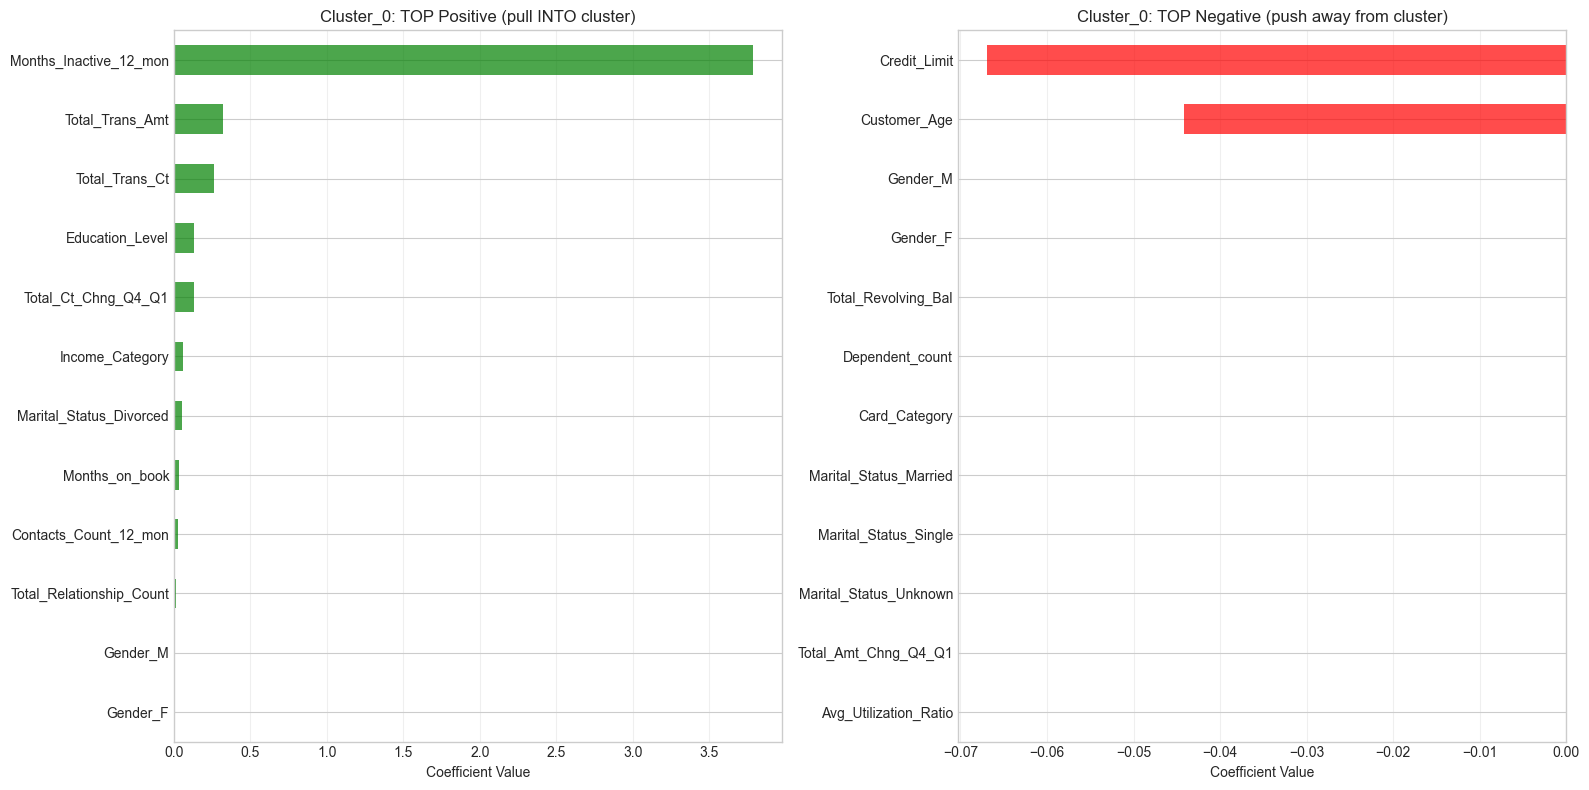


Cluster_1

--- TOP POSITIVE (pull Cluster_1) ---


,coefficient
Months_Inactive_12_mon,0.510405
Total_Relationship_Count,0.184325
Card_Category,0.147848
Months_on_book,0.111432
Customer_Age,0.047714
Gender_F,0.010843
Credit_Limit,0.000000
Total_Revolving_Bal,0.000000
Total_Amt_Chng_Q4_Q1,0.000000
Income_Category,0.000000



--- TOP NEGATIVE (push away from Cluster_1) ---


,coefficient
Total_Trans_Amt,-19.678868
Total_Trans_Ct,-9.888832
Education_Level,-0.083014
Marital_Status_Divorced,-0.080228
Contacts_Count_12_mon,-0.065003
Gender_M,-0.010843
Marital_Status_Unknown,0.000000
Marital_Status_Single,0.000000
Total_Ct_Chng_Q4_Q1,0.000000
Avg_Utilization_Ratio,0.000000


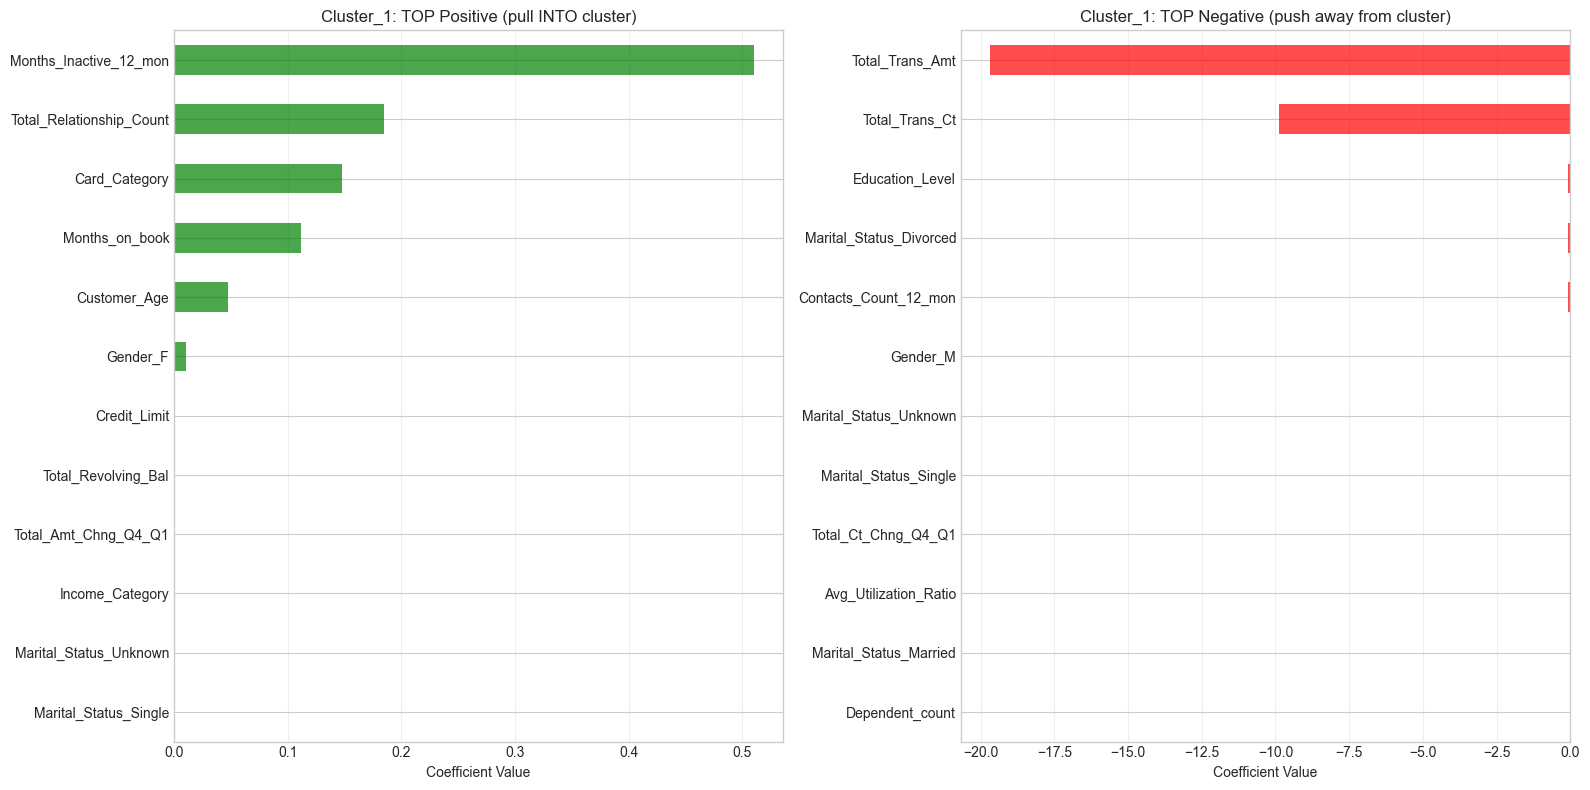


Cluster_2

--- TOP POSITIVE (pull Cluster_2) ---


,coefficient
Total_Trans_Ct,8.001308
Total_Trans_Amt,7.338416
Credit_Limit,0.313900
Marital_Status_Married,0.036109
Dependent_count,0.016475
Card_Category,0.000000
Total_Amt_Chng_Q4_Q1,0.000000
Contacts_Count_12_mon,0.000000
Customer_Age,0.000000
Gender_M,0.000000



--- TOP NEGATIVE (push away from Cluster_2) ---


,coefficient
Income_Category,-0.314968
Total_Ct_Chng_Q4_Q1,-0.289072
Education_Level,-0.163108
Total_Relationship_Count,-0.129206
Avg_Utilization_Ratio,-0.116474
Marital_Status_Divorced,-0.062057
Months_on_book,-0.060589
Marital_Status_Unknown,-0.043588
Total_Revolving_Bal,-0.010669
Months_Inactive_12_mon,-0.000041


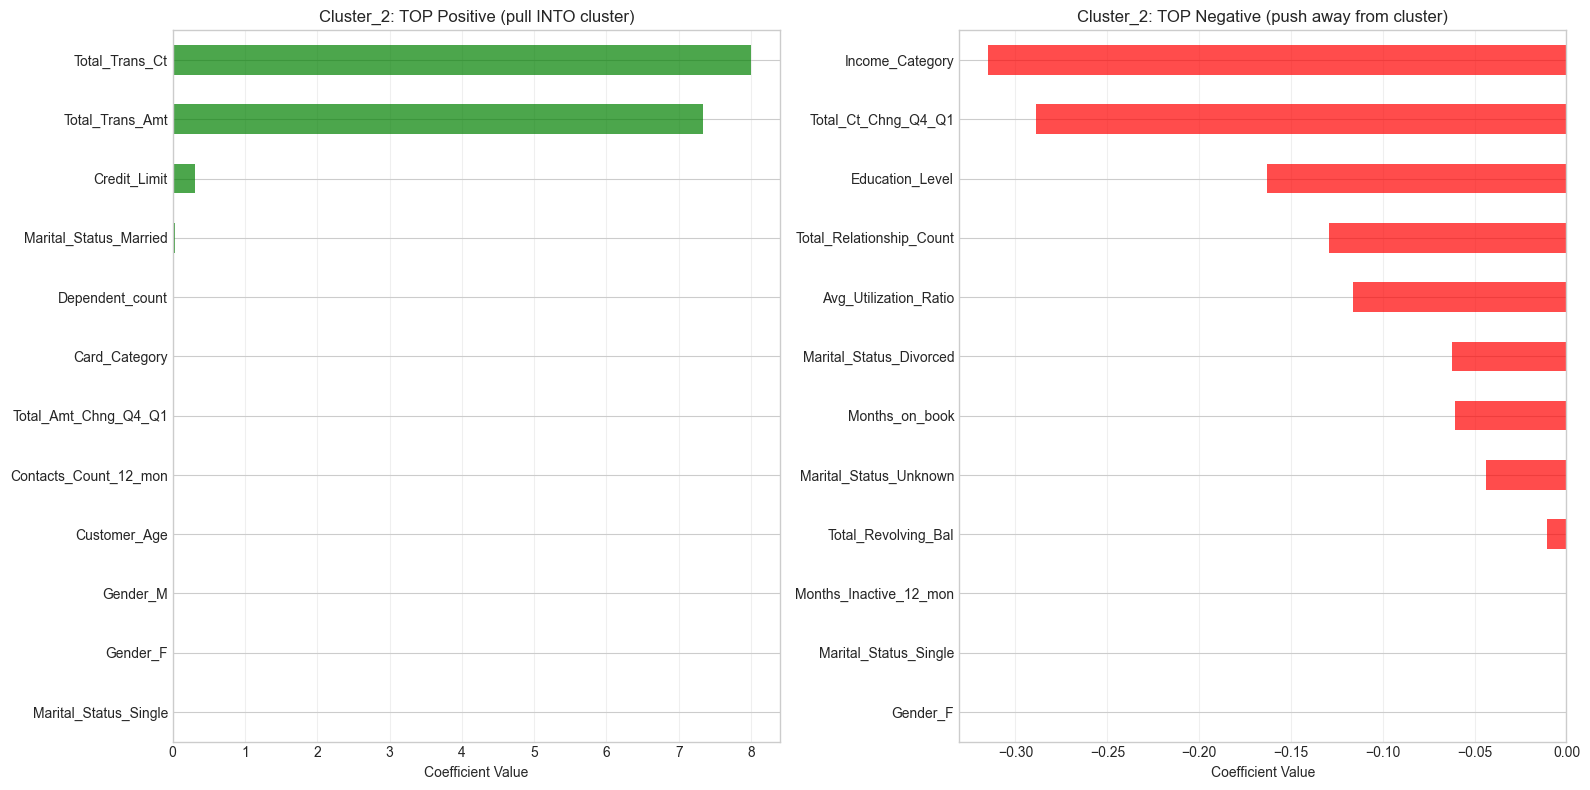


Cluster_3

--- TOP POSITIVE (pull Cluster_3) ---


,coefficient
Total_Ct_Chng_Q4_Q1,0.127175
Marital_Status_Divorced,0.082547
Marital_Status_Unknown,0.055141
Total_Amt_Chng_Q4_Q1,0.052819
Education_Level,0.025722
Total_Revolving_Bal,0.017812
Avg_Utilization_Ratio,0.010808
Gender_M,0.000898
Income_Category,0.000000
Credit_Limit,0.000000



--- TOP NEGATIVE (push away from Cluster_3) ---


,coefficient
Months_Inactive_12_mon,-5.340044
Total_Relationship_Count,-0.145523
Card_Category,-0.045554
Months_on_book,-0.015315
Marital_Status_Single,-0.003808
Gender_F,-0.000898
Contacts_Count_12_mon,0.000000
Marital_Status_Married,0.000000
Total_Trans_Ct,0.000000
Total_Trans_Amt,0.000000


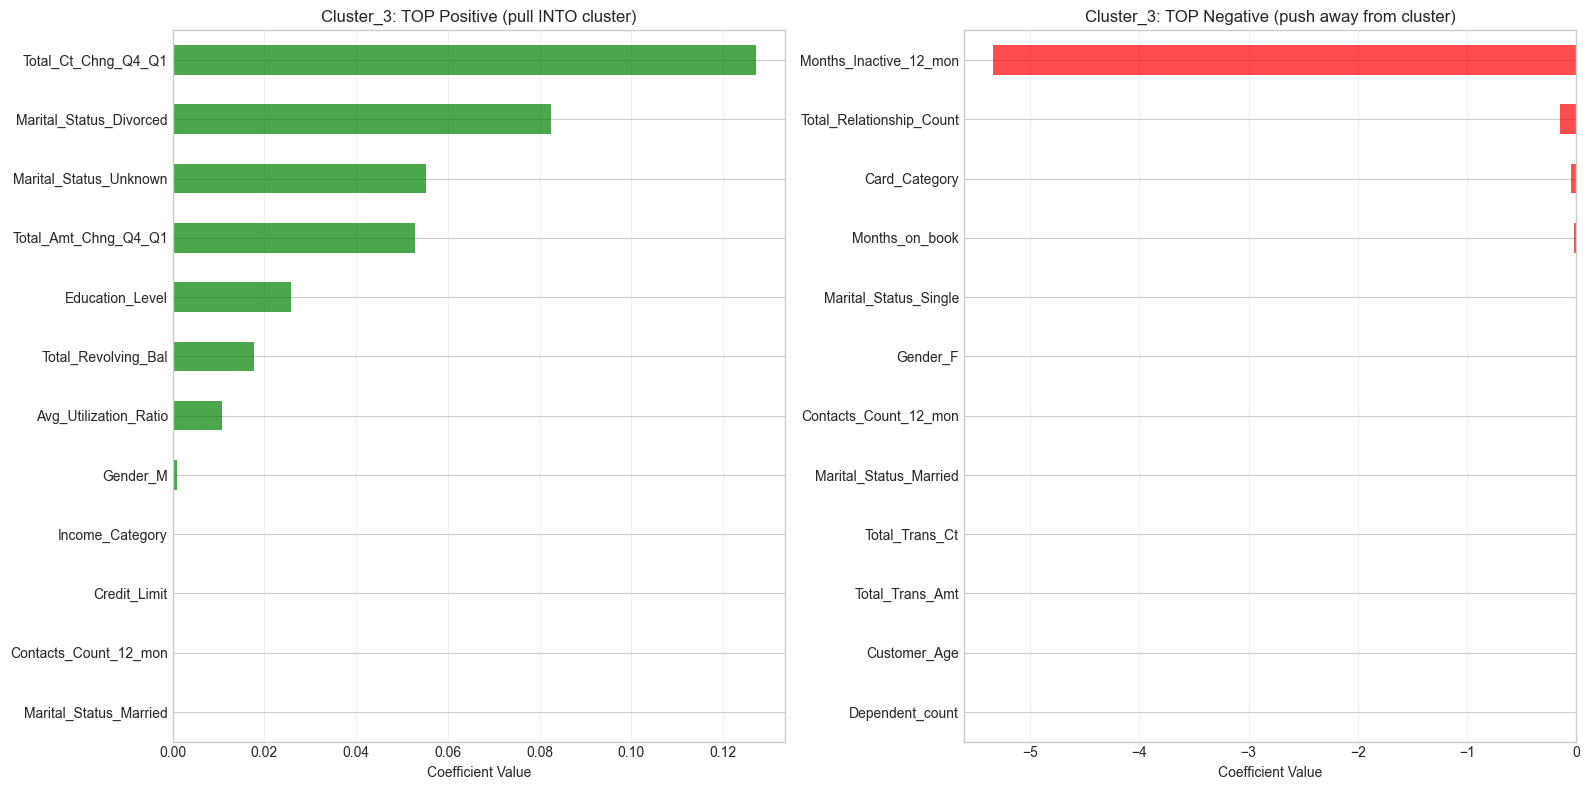

In [43]:
# 5. Detailed analysis coefficient for each class
print("\n" + "="*60)
print("PER-CLASS COEFFICIENT ANALYSIS")
print("="*60)

for class_name in coef_df.index:
    print(f"\n{'='*60}")
    print(f"{class_name}")
    print("="*60)
    
    top_pos, top_neg = show_top_coefs_for_class(coef_df, class_name, top_n=12)
    
    print(f"\n--- TOP POSITIVE (pull {class_name}) ---")
    display(top_pos.to_frame("coefficient"))
    
    print(f"\n--- TOP NEGATIVE (push away from {class_name}) ---")
    display(top_neg.to_frame("coefficient"))
    
    # Visualize
    plot_class_coefficients(coef_df, class_name, top_n=12)

**Cluster 0:**

The main driver for this group is the number of inactive months, which has a strong positive score of 3.5. There are also small positive factors like the total amount spent (0.15) and the number of transactions (0.1). On the other hand, factors like credit limit (-0.07) and customer age (-0.06) have negative scores. This means that customers with lower credit limits and younger ages are more likely to land in this group.

Cluster 0 consists of customers with high inactivity periods but occasionally make transactions. They are characterized by long periods without activity combined with low credit limits, representing disengaged or dormant customers.

**Cluster 1:**

This group is defined by customers who have been with the bank for a long time (0.2) and hold multiple products (0.2). Other positive factors include having higher-tier cards (0.2) and moderate periods of inactivity (0.5). On the other hand, actual usage has a massive negative impact. The total amount of money spent (-20.0) and the number of transactions (-17.5) have very strong negative scores. This means that customers who spend a lot or use their cards frequently do not belong in this group.

Cluster 1 represents long-term, multi-product customers with low transaction activity. These customers maintain relationships through multiple products (cards, accounts) and longer tenure, but they transact infrequently and with small amounts - likely relationship banking customers who hold accounts but don't actively use them.

**Cluster 2:**

This group is driven mainly by heavy usage. The number of transactions (7.5) and the total amount spent (6.5) have very high positive scores, making them the strongest predictors. Higher credit limits (0.1) also play a small positive role. Conversely, factors like income level (-0.3), slowing transaction trends (-0.25), education level (-0.25), and the number of bank products (-0.2) have negative scores, meaning these traits are less common in this active group.

Cluster 2 contains highly active transactors with high spending. They are defined by extremely high transaction volumes and amounts, representing the most engaged and valuable customers from a transaction perspective, even though they may have fewer total banking products.

**Cluster 3:**

The most distinct feature of this group is that they are almost never inactive. The number of inactive months has a very strong negative score of -6.0, which pushes inactive people away from this cluster. On the positive side, these customers show an upward trend in activity. The frequency of their transactions (0.12) and the amount they spend (0.06) are increasing compared to the start of the year. Personal details like being divorced (0.1) or having a higher education level (0.04) are also small positive indicators for this group.

Cluster 3 represents customers showing growth in transaction behavior. They are characterized by increasing transaction trends (Q4 vs Q1) and minimal inactivity, suggesting customers whose engagement is growing or changing, possibly responding to life events (divorced/unknown marital status) or developing stronger banking relationships.

Looking at the story across all four groups, the most important plot point is transaction behavior. The data shows that how often customers swipe their cards and how much they spend are the main things that make them different from each other.

We see a clear "battle of opposites" between Cluster 1 and Cluster 2. One group focuses on having relationships and products but rarely spends, while the other spends heavily but holds fewer products. The dividing line in this story is inactivity. The number of dormant months acts as a wall that separates the engaged customers (Clusters 2 and 3) from the disengaged ones (Clusters 0 and 1). Finally, it turns out that personal details like education and income are just minor characters in this story—ultimately, what customers do with their accounts matters much more than who they are.

### Statistics of coefficients

In [44]:
# 6. Statistics of coefficients
print("\n" + "="*60)
print("COEFFICIENT STATISTICS")
print("="*60)

stats_df = pd.DataFrame({
    'Mean': coef_df.mean(axis=1),
    'Std': coef_df.std(axis=1),
    'Min': coef_df.min(axis=1),
    'Max': coef_df.max(axis=1),
    'Range': coef_df.max(axis=1) - coef_df.min(axis=1)
})
display(stats_df)


COEFFICIENT STATISTICS


,Mean,Std,Min,Max,Range
Cluster_0,0.213713,0.803777,-0.066944,3.788494,3.855438
Cluster_1,-1.308828,4.617302,-19.678868,0.510405,20.189272
Cluster_2,0.659838,2.274539,-0.314968,8.001308,8.316276
Cluster_3,-0.235374,1.141233,-5.340044,0.127175,5.467219


Looking at the coefficient statistics table, Cluster 1 stands out as the most unique group with extremely high variation (Std = 4.62, Range = 20.19). This means this customer group is defined by very strong and opposite forces - they have extremely negative coefficients for transactions (-20.0) but positive coefficients for other factors. The Mean = -1.31 shows that overall, this group "avoids" transaction-related characteristics.

In contrast, Cluster 0 is the most balanced group (Std = 0.80, Range = 3.86) with Mean = 0.21 close to zero, meaning no single factor dominates this group - these are "neutral" customers.

Cluster 2 has the highest positive Mean (0.66) and moderate variation (Std = 2.27, Range = 8.32), showing this group is clearly defined by positive factors like high transaction volume and spending.

Cluster 3 falls in the middle with Mean = -0.24, Std = 1.14, and Range = 5.47 - they have relatively stable characteristics but slightly lean toward avoiding inactive behaviors.

The size of Std and Range tells us whether a cluster is defined by strong, distinct factors or not - Cluster 1 has the strongest defining features, while Cluster 0 is the hardest to distinguish.

### Optuna with important features

ElasticNet feature selection uses a combination of L1 and L2 regularization to identify the most important features before hyperparameter tuning. 

The key parameters are set as follows: 
+ penalty='elasticnet' enables this combined approach where L1 removes unimportant features by shrinking their coefficients to zero, while L2 keeps the model stable and handles correlated features. 
+ The solver='saga' is required because it's the only solver that supports ElasticNet in scikit-learn. The l1_ratio parameter (tested from 0.1 to 0.9) controls the balance between L1 and L2 - higher values mean more aggressive feature removal. 
+ We set max_iter=2000 to give the model enough time to converge, and C=1.0 as a standard regularization strength for feature ranking purposes (not for final performance). 
+ The multi_class='multinomial' handles our 4-cluster problem by optimizing all classes together. 

This two-step approach first identifies which features matter most using ElasticNet, then lets Optuna fine-tune the hyperparameters on those selected features, resulting in a simpler and more efficient model.

In [45]:
def get_top_important_features_elasticnet(X_train, y_train, top_n=20, l1_ratio=0.5):
    """
    Lấy top important features sử dụng ElasticNet (L1+L2 regularization)
    
    Parameters:
    -----------
    X_train, y_train : training data
    top_n : số lượng top features
    l1_ratio : tỷ lệ L1 penalty (0=L2 only, 1=L1 only, 0.5=balanced)
    
    Returns:
    --------
    list : danh sách tên features quan trọng nhất
    array : importance scores
    """
    print(f"\n=== ELASTICNET FEATURE SELECTION (l1_ratio={l1_ratio}) ===")
    
    # Create ElasticNet pipeline
    elasticnet_pipeline = Pipeline([
        ("preprocessor", base_preprocessor),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=l1_ratio,
            max_iter=2000,
            random_state=RANDOM_STATE,
            multi_class='multinomial',
            C=1.0 
        ))
    ])
    
    # Fit model
    print("Training ElasticNet model for feature selection...")
    elasticnet_pipeline.fit(X_train, y_train)
    print("✓ Done")
    
    # Get feature names
    feat_names = get_feature_names_from_pipeline(elasticnet_pipeline)
    
    # Get classifier
    clf = elasticnet_pipeline.named_steps["classifier"]
    
    # Get coefficients
    coefs = clf.coef_
    
    # Importance = mean(|coef|)
    importance = np.mean(np.abs(coefs), axis=0)
    
    # Count non-zero coefficients (ElasticNet feature)
    non_zero_mask = np.any(coefs != 0, axis=0)
    n_non_zero = non_zero_mask.sum()
    
    print(f"Non-zero features: {n_non_zero}/{len(feat_names)}")
    
    # Get top features
    top_indices = np.argsort(importance)[::-1][:top_n]
    top_feature_names = [feat_names[i] for i in top_indices]
    top_importances = importance[top_indices]
    
    # Show sparsity info
    print(f"\nSparsity by class:")
    for i, class_label in enumerate(clf.classes_):
        non_zero_per_class = (coefs[i] != 0).sum()
        print(f"  Cluster {class_label}: {non_zero_per_class}/{len(feat_names)} non-zero features")
    
    return top_feature_names, top_importances, elasticnet_pipeline

In [46]:
def create_feature_selector(pipeline, important_features):
    """
    Tạo preprocessor mới chỉ với important features
    
    Parameters:
    -----------
    pipeline : original pipeline
    important_features : list of important feature names
    
    Returns:
    --------
    ColumnTransformer : preprocessor mới
    """
    # Phân loại features theo loại
    selected_ordinal = [f for f in ordinal_cols if f in important_features]
    selected_nominal = [f for f in nominal_cols if f in important_features]
    selected_numeric = [f for f in numeric_cols if f in important_features]
    
    # Lấy OneHot features (cần check prefix)
    selected_nominal_expanded = []
    for nom_col in nominal_cols:
        matching_features = [f for f in important_features if f.startswith(nom_col + '_')]
        if matching_features:
            selected_nominal_expanded.append(nom_col)
    
    # Unique nominal columns
    selected_nominal_final = list(set(selected_nominal + selected_nominal_expanded))
    
    print(f"\n=== SELECTED FEATURES ===")
    print(f"Ordinal: {len(selected_ordinal)} - {selected_ordinal}")
    print(f"Nominal: {len(selected_nominal_final)} - {selected_nominal_final}")
    print(f"Numeric: {len(selected_numeric)} - {selected_numeric}")
    
    # Create new preprocessor
    transformers = []
    
    if selected_ordinal:
        ord_indices = [ordinal_cols.index(col) for col in selected_ordinal]
        ord_cats = [ordinal_categories[i] for i in ord_indices]
        transformers.append(
            ("ord", OrdinalEncoder(
                categories=ord_cats,
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ), selected_ordinal)
        )
    
    if selected_nominal_final:
        transformers.append(
            ("nom", OneHotEncoder(handle_unknown="ignore"), selected_nominal_final)
        )
    
    if selected_numeric:
        transformers.append(
            ("num", "passthrough", selected_numeric)
        )
    
    feature_preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )
    
    return feature_preprocessor

In [47]:
def objective_with_feature_selection(trial, important_features=None):
    """
    Optuna objective với feature selection
    
    Parameters:
    -----------
    trial : Optuna trial
    important_features : list of important features (nếu None thì dùng all features)
    
    Returns:
    --------
    float : mean CV score
    """
    # Hyperparameters
    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet', None])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    
    # Solver conditional on penalty
    if penalty == 'l1':
        solver = 'saga' 
    elif penalty == 'l2':
        solver = trial.suggest_categorical('solver_l2', ['lbfgs', 'saga', 'newton-cg', 'sag'])
    elif penalty == 'elasticnet':
        solver = 'saga'
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    else:  # None
        solver = trial.suggest_categorical('solver_none', ['lbfgs', 'saga', 'newton-cg', 'sag'])
    
    if important_features is not None:
        n_features = trial.suggest_int('n_features', 3, len(important_features))
        selected_features = important_features[:n_features]
        preprocessor = create_feature_selector(None, selected_features)
    else:
        preprocessor = base_preprocessor
    
    # Create params
    params = {
        'C': C,
        'penalty': penalty,
        'solver': solver,
        'class_weight': class_weight,
        'max_iter': 2000,
        'random_state': RANDOM_STATE,
        'multi_class': 'multinomial'
    }
    
    if penalty == 'elasticnet':
        params['l1_ratio'] = l1_ratio
    
    # Create pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(**params))
    ])
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    try:
        scores = cross_val_score(
            pipeline, 
            X_train, 
            y_train, 
            cv=cv,
            scoring='f1_macro',
            n_jobs=-1
        )
        return scores.mean()
    except Exception as e:
        print(f"Trial failed: {e}")
        return 0.0

In [48]:
def find_best_l1_ratio_for_feature_selection(X_train, y_train, l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9]):
    """
    Tìm l1_ratio tốt nhất cho ElasticNet feature selection
    
    Parameters:
    -----------
    X_train, y_train : training data
    l1_ratios : list of l1_ratio values to try
    
    Returns:
    --------
    best_l1_ratio, results_df
    """
    print("="*60)
    print("FINDING BEST L1_RATIO FOR ELASTICNET FEATURE SELECTION")
    print("="*60)
    
    results = []
    
    for l1_ratio in l1_ratios:
        print(f"\nTrying l1_ratio = {l1_ratio}...")
        
        # Create pipeline
        pipeline = Pipeline([
            ("preprocessor", base_preprocessor),
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                penalty='elasticnet',
                solver='saga',
                l1_ratio=l1_ratio,
                max_iter=2000,
                random_state=RANDOM_STATE,
                multi_class='multinomial',
                C=1.0
            ))
        ])
        
        # Cross-validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')
        
        # Get coefficients
        pipeline.fit(X_train, y_train)
        coefs = pipeline.named_steps["classifier"].coef_
        non_zero_features = np.any(coefs != 0, axis=0).sum()
        
        results.append({
            'l1_ratio': l1_ratio,
            'cv_f1_macro_mean': scores.mean(),
            'cv_f1_macro_std': scores.std(),
            'non_zero_features': non_zero_features
        })
        
        print(f"  CV F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}")
        print(f"  Non-zero features: {non_zero_features}")
    
    results_df = pd.DataFrame(results)
    best_idx = results_df['cv_f1_macro_mean'].idxmax()
    best_l1_ratio = results_df.loc[best_idx, 'l1_ratio']
    
    print("\n" + "="*60)
    print("RESULTS")
    print("="*60)
    display(results_df)
    print(f"\nBest l1_ratio: {best_l1_ratio}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: CV Score vs l1_ratio
    axes[0].errorbar(results_df['l1_ratio'], results_df['cv_f1_macro_mean'], 
                     yerr=results_df['cv_f1_macro_std'], marker='o', capsize=5)
    axes[0].set_xlabel('L1 Ratio')
    axes[0].set_ylabel('CV F1-Macro Score')
    axes[0].set_title('Performance vs L1 Ratio')
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(best_l1_ratio, color='red', linestyle='--', label=f'Best: {best_l1_ratio}')
    axes[0].legend()
    
    # Plot 2: Number of non-zero features
    axes[1].plot(results_df['l1_ratio'], results_df['non_zero_features'], marker='s', color='orange')
    axes[1].set_xlabel('L1 Ratio')
    axes[1].set_ylabel('Number of Non-Zero Features')
    axes[1].set_title('Feature Sparsity vs L1 Ratio')
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(best_l1_ratio, color='red', linestyle='--', label=f'Best: {best_l1_ratio}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return best_l1_ratio, results_df

ELASTICNET-BASED FEATURE SELECTION
FINDING BEST L1_RATIO FOR ELASTICNET FEATURE SELECTION

Trying l1_ratio = 0.1...


c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 an

  CV F1-Macro: 0.9131 ± 0.0029
  Non-zero features: 22

Trying l1_ratio = 0.3...


c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 an

  CV F1-Macro: 0.9131 ± 0.0032
  Non-zero features: 22

Trying l1_ratio = 0.5...


...

  CV F1-Macro: 0.9134 ± 0.0039
  Non-zero features: 22

Trying l1_ratio = 0.9...


c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 an

  CV F1-Macro: 0.9134 ± 0.0035
  Non-zero features: 21

RESULTS


,l1_ratio,cv_f1_macro_mean,cv_f1_macro_std,non_zero_features
0,0.1,0.913115,0.002894,22
1,0.3,0.913109,0.003205,22
2,0.5,0.912832,0.002705,22
3,0.7,0.913363,0.003871,22
4,0.9,0.913432,0.003509,21



Best l1_ratio: 0.9


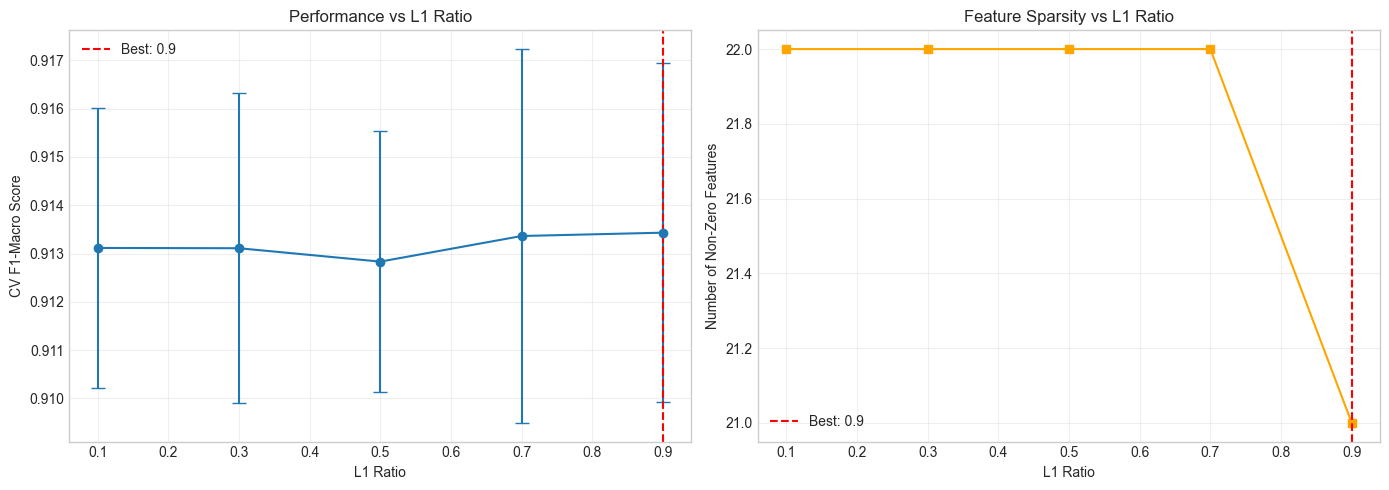


=== ELASTICNET FEATURE SELECTION (l1_ratio=0.9) ===
Training ElasticNet model for feature selection...


c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



✓ Done
Non-zero features: 21/22

Sparsity by class:
  Cluster 0: 15/22 non-zero features
  Cluster 1: 18/22 non-zero features
  Cluster 2: 17/22 non-zero features
  Cluster 3: 13/22 non-zero features

Top 5 Important Features (ElasticNet):
 1. Total_Trans_Amt                - 6.4165
 2. Total_Trans_Ct                 - 4.2936
 3. Months_Inactive_12_mon         - 2.3133
 4. Total_Ct_Chng_Q4_Q1            - 0.1428
 5. Total_Relationship_Count       - 0.1368


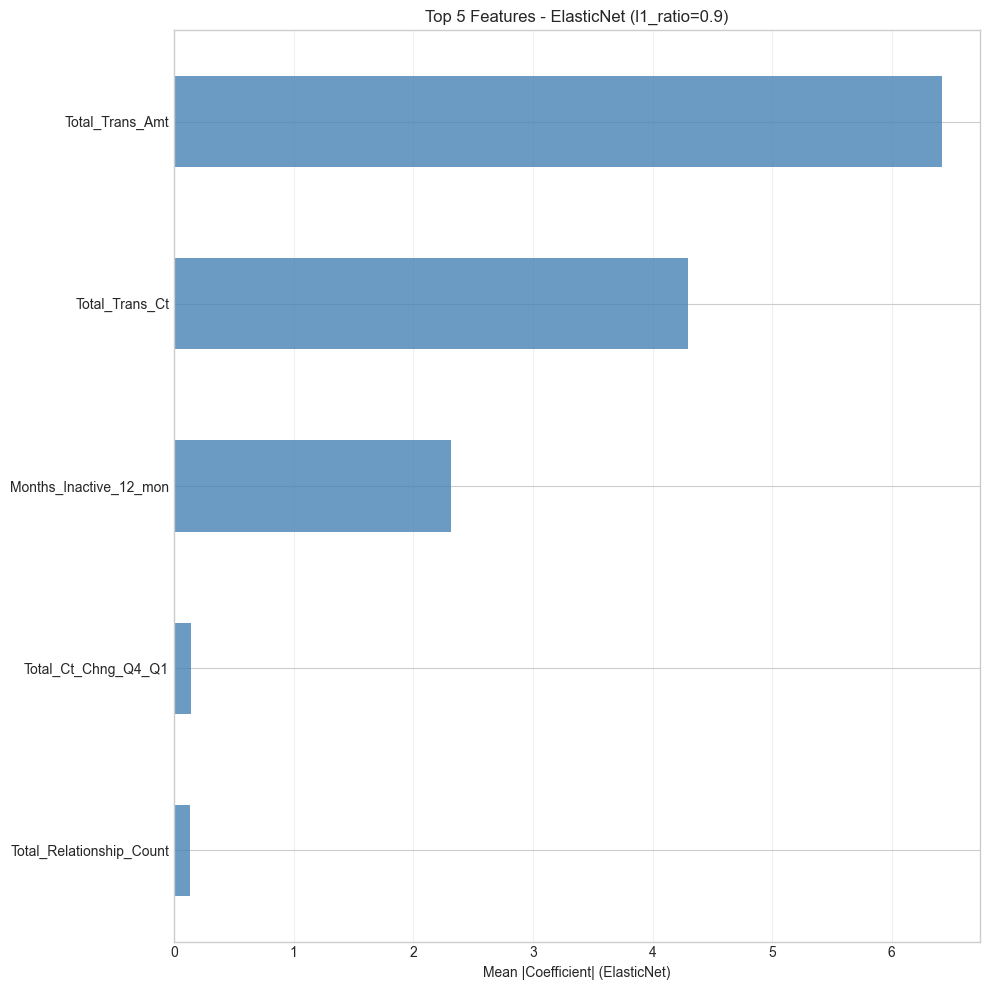

In [55]:
print("="*60)
print("ELASTICNET-BASED FEATURE SELECTION")
print("="*60)

# BƯỚC 1: Tìm l1_ratio tốt nhất (optional - có thể skip nếu muốn dùng 0.5)
best_l1_ratio, l1_results = find_best_l1_ratio_for_feature_selection(
    X_train, y_train, 
    l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9]
)

# BƯỚC 2: Lấy important features với l1_ratio tốt nhất
top_features, importances, elasticnet_model = get_top_important_features_elasticnet(
    X_train, y_train, 
    top_n=5,
    l1_ratio=best_l1_ratio
)

print(f"\nTop {len(top_features)} Important Features (ElasticNet):")
for i, (feat, imp) in enumerate(zip(top_features[:5], importances[:5]), 1):
    print(f"{i:2d}. {feat:30s} - {imp:.4f}")

# BƯỚC 3: Visualize importance
plt.figure(figsize=(10, 10))
pd.Series(importances[:5], index=top_features[:5]).plot(kind='barh', color='steelblue', alpha=0.8)
plt.xlabel('Mean |Coefficient| (ElasticNet)')
plt.title(f'Top 5 Features - ElasticNet (l1_ratio={best_l1_ratio})')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


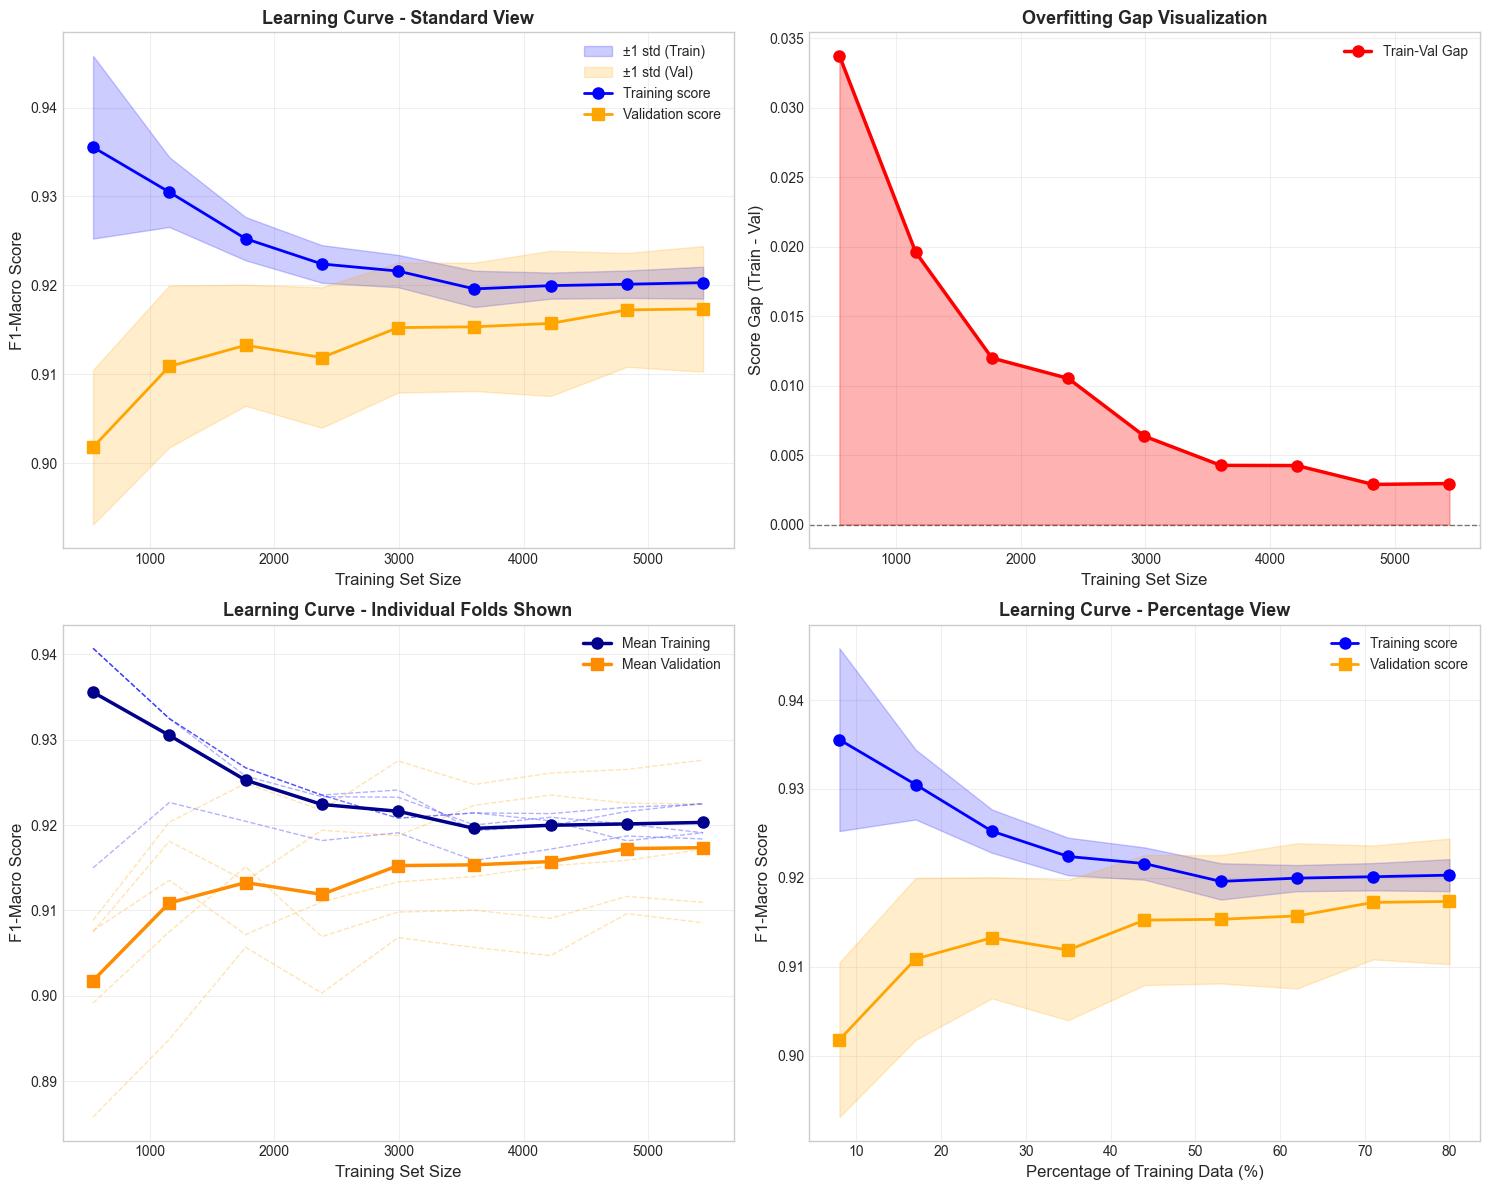


LEARNING CURVE ANALYSIS - DETAILED METRICS
Dataset Size:   544 | Train: 0.9355 ± 0.0103 | Val: 0.9018 ± 0.0087 | Gap: 0.0337
Dataset Size:  1156 | Train: 0.9305 ± 0.0039 | Val: 0.9109 ± 0.0091 | Gap: 0.0196
Dataset Size:  1768 | Train: 0.9253 ± 0.0024 | Val: 0.9133 ± 0.0068 | Gap: 0.0120
Dataset Size:  2380 | Train: 0.9224 ± 0.0021 | Val: 0.9119 ± 0.0079 | Gap: 0.0105
Dataset Size:  2992 | Train: 0.9216 ± 0.0018 | Val: 0.9153 ± 0.0073 | Gap: 0.0064
Dataset Size:  3604 | Train: 0.9196 ± 0.0020 | Val: 0.9153 ± 0.0072 | Gap: 0.0043
Dataset Size:  4216 | Train: 0.9200 ± 0.0015 | Val: 0.9157 ± 0.0082 | Gap: 0.0042
Dataset Size:  4828 | Train: 0.9201 ± 0.0015 | Val: 0.9172 ± 0.0064 | Gap: 0.0029
Dataset Size:  5440 | Train: 0.9203 ± 0.0018 | Val: 0.9174 ± 0.0071 | Gap: 0.0030


In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

# Create different learning curve visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Standard Learning Curve with Confidence Interval
ax = axes[0, 0]
train_sizes_abs, train_scores, val_scores = learning_curve(
    final_logistic_pipeline, X_train, y_train, 
    cv=5, scoring='f1_macro', train_sizes=np.linspace(0.1, 1.0, 9),
    n_jobs=-1, random_state=42
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue', label='±1 std (Train)')
ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange', label='±1 std (Val)')
ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training score', linewidth=2, markersize=8)
ax.plot(train_sizes_abs, val_mean, 's-', color='orange', label='Validation score', linewidth=2, markersize=8)
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('F1-Macro Score', fontsize=12)
ax.set_title('Learning Curve - Standard View', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# 2. Absolute Difference (Gap) Between Train and Validation
ax = axes[0, 1]
gap = train_mean - val_mean
ax.plot(train_sizes_abs, gap, 'o-', color='red', linewidth=2.5, markersize=8, label='Train-Val Gap')
ax.fill_between(train_sizes_abs, gap, alpha=0.3, color='red')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Score Gap (Train - Val)', fontsize=12)
ax.set_title('Overfitting Gap Visualization', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# 3. Learning Curve with All Folds (Individual folds)
ax = axes[1, 0]
# Iterate over folds (columns) not training sizes
for fold_idx in range(train_scores.shape[1]):
    ax.plot(train_sizes_abs, train_scores[:, fold_idx], '--', alpha=0.3, color='blue', linewidth=1)
    ax.plot(train_sizes_abs, val_scores[:, fold_idx], '--', alpha=0.3, color='orange', linewidth=1)
ax.plot(train_sizes_abs, train_mean, 'o-', color='darkblue', label='Mean Training', linewidth=2.5, markersize=8)
ax.plot(train_sizes_abs, val_mean, 's-', color='darkorange', label='Mean Validation', linewidth=2.5, markersize=8)
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('F1-Macro Score', fontsize=12)
ax.set_title('Learning Curve - Individual Folds Shown', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# 4. Learning Curve with Percentage
ax = axes[1, 1]
train_pct = (train_sizes_abs / X_train.shape[0]) * 100
ax.plot(train_pct, train_mean, 'o-', color='blue', label='Training score', linewidth=2, markersize=8)
ax.plot(train_pct, val_mean, 's-', color='orange', label='Validation score', linewidth=2, markersize=8)
ax.fill_between(train_pct, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
ax.fill_between(train_pct, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
ax.set_xlabel('Percentage of Training Data (%)', fontsize=12)
ax.set_ylabel('F1-Macro Score', fontsize=12)
ax.set_title('Learning Curve - Percentage View', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("LEARNING CURVE ANALYSIS - DETAILED METRICS")
print("="*60)
for i, size in enumerate(train_sizes_abs):
    gap = train_mean[i] - val_mean[i]
    print(f"Dataset Size: {int(size):5d} | Train: {train_mean[i]:.4f} ± {train_std[i]:.4f} | "
          f"Val: {val_mean[i]:.4f} ± {val_std[i]:.4f} | Gap: {gap:.4f}")


In [50]:
print("\n=== OPTUNA TUNING WITH ELASTICNET-SELECTED FEATURES ===")

study_with_fs = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='logistic_regression_with_elasticnet_features'
)

def objective_wrapper(trial):
    return objective_with_feature_selection(trial, important_features=top_features)

study_with_fs.optimize(
    objective_wrapper,
    n_trials=100,
    show_progress_bar=True,
    n_jobs=1
)

print("\n" + "="*60)
print("RESULTS")
print("="*60)
print(f"Best f1_macro: {study_with_fs.best_value:.4f}")
print(f"Best params: {study_with_fs.best_params}")

[I 2026-05-12 03:09:16,205] A new study created in memory with name: logistic_regression_with_elasticnet_features



=== OPTUNA TUNING WITH ELASTICNET-SELECTED FEATURES ===


  0%|          | 0/100 [00:00<?, ?it/s]


=== SELECTED FEATURES ===
Ordinal: 0 - []
Nominal: 0 - []
Numeric: 5 - ['Total_Relationship_Count', 'Months_Inactive_12_mon', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1']


Best trial: 0. Best value: 0.896501:   1%|          | 1/100 [00:00<00:12,  7.77it/s]

...

[I 2026-05-12 03:10:37,843] Trial 97 finished with value: 0.9192482628631531 and parameters: {'C': 36.089974808381484, 'penalty': 'elasticnet', 'class_weight': None, 'l1_ratio': 0.14398666698545864, 'n_features': 4}. Best is trial 94 with value: 0.9192482628631531.

=== SELECTED FEATURES ===
Ordinal: 0 - []
Nominal: 0 - []
Numeric: 4 - ['Months_Inactive_12_mon', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1']


Best trial: 94. Best value: 0.919248:  99%|█████████▉| 99/100 [01:24<00:02,  2.85s/it]

[I 2026-05-12 03:10:40,602] Trial 98 finished with value: 0.9192482628631531 and parameters: {'C': 36.03182056742401, 'penalty': 'elasticnet', 'class_weight': None, 'l1_ratio': 0.11605084632954644, 'n_features': 4}. Best is trial 94 with value: 0.9192482628631531.

=== SELECTED FEATURES ===
Ordinal: 0 - []
Nominal: 0 - []
Numeric: 4 - ['Months_Inactive_12_mon', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1']


Best trial: 94. Best value: 0.919248: 100%|██████████| 100/100 [01:26<00:00,  1.15it/s]

[I 2026-05-12 03:10:43,064] Trial 99 finished with value: 0.9192482628631531 and parameters: {'C': 36.69382061827794, 'penalty': 'elasticnet', 'class_weight': None, 'l1_ratio': 0.11630507519323824, 'n_features': 4}. Best is trial 94 with value: 0.9192482628631531.

RESULTS
Best f1_macro: 0.9192
Best params: {'C': 33.30818321796491, 'penalty': 'elasticnet', 'class_weight': None, 'l1_ratio': 0.23015458465995556, 'n_features': 4}


In [51]:
print("\n" + "="*60)
print("BEST FEATURES INFORMATION")
print("="*60)

best_n_features = study_with_fs.best_params.get('n_features', len(top_features))
best_selected_features = top_features[:best_n_features]

print(f"\nNumber of features used: {best_n_features}")
print(f"\nFeatures used with best parameters:")
for i, feat in enumerate(best_selected_features, 1):
    print(f"{i:2d}. {feat}")

print("\n" + "="*60)


BEST FEATURES INFORMATION

Number of features used: 4

Features used with best parameters:
 1. Total_Trans_Amt
 2. Total_Trans_Ct
 3. Months_Inactive_12_mon
 4. Total_Ct_Chng_Q4_Q1



c:\Users\dangn\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.




=== STEP 3: Retrain with Best Parameters (Feature Selection) ===
Using top 4 features

=== SELECTED FEATURES ===
Ordinal: 0 - []
Nominal: 0 - []
Numeric: 4 - ['Months_Inactive_12_mon', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1']

Training model with feature selection...
✓ Model has been trained!
Logistic Regression (Feature Selection - Top 4) - PERFORMANCE EVALUATION

--- TRAIN SET ---
Accuracy:          0.9040
F1-Macro:          0.9195
F1-Weighted:       0.9039
Balanced Accuracy: 0.9273

--- TEST SET ---
Accuracy:          0.8971
F1-Macro:          0.9159
F1-Weighted:       0.8972
Balanced Accuracy: 0.9246

--- CLASSIFICATION REPORT (TEST) ---
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       613
           1       0.98      0.99      0.98       425
           2       0.98      0.99      0.98       190
           3       0.74      0.98      0.84       472

    accuracy                           0.90      1700
   m

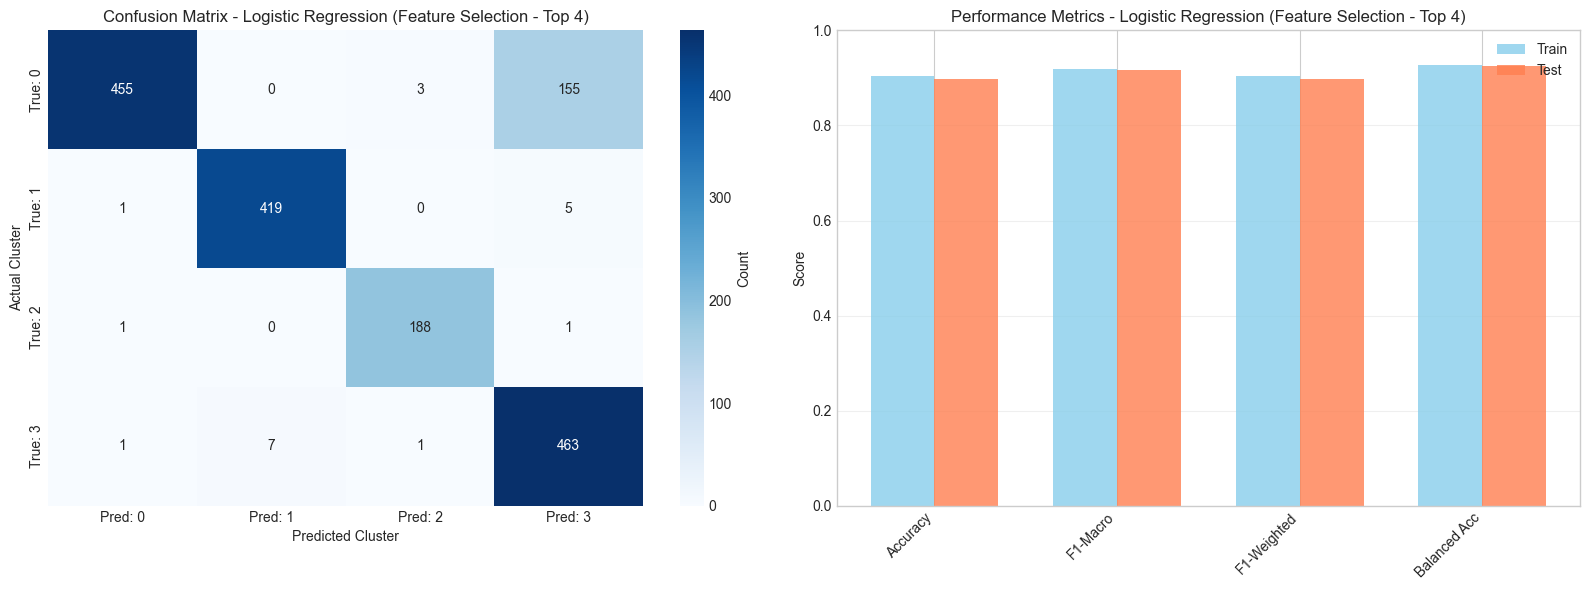


--- PROBABILITY-BASED METRICS (TEST) ---
Log Loss: 0.1759
ROC-AUC (OvR, macro): 0.9860



In [52]:
# 4. Retrain với best params từ feature selection
print("\n=== STEP 3: Retrain with Best Parameters (Feature Selection) ===")

best_params_fs = study_with_fs.best_params.copy()

# Extract solver
if 'solver_l2' in best_params_fs:
    solver = best_params_fs.pop('solver_l2')
elif 'solver_none' in best_params_fs:
    solver = best_params_fs.pop('solver_none')
else:
    solver = 'saga'

# Extract l1_ratio
if best_params_fs.get('penalty') == 'elasticnet':
    l1_ratio = best_params_fs.pop('l1_ratio', 0.5)
else:
    l1_ratio = None
    best_params_fs.pop('l1_ratio', None)

# Extract n_features
n_features = best_params_fs.pop('n_features', len(top_features))
selected_features = top_features[:n_features]

print(f"Using top {n_features} features")

# Create preprocessor with selected features
selected_preprocessor = create_feature_selector(None, selected_features)

best_params_fs['solver'] = solver

# Create final pipeline
final_pipeline_with_fs = Pipeline([
    ("preprocessor", selected_preprocessor),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        **best_params_fs,
        l1_ratio=l1_ratio if best_params_fs.get('penalty') == 'elasticnet' else None,
        max_iter=2000,
        random_state=RANDOM_STATE,
        multi_class='multinomial'
    ))
])

# Train
print("\nTraining model with feature selection...")
final_pipeline_with_fs.fit(X_train, y_train)
print("✓ Model has been trained!")

# Evaluate
fs_metrics = evaluate_model(
    final_pipeline_with_fs,
    X_train, y_train,
    X_test, y_test,
    label=f"Logistic Regression (Feature Selection - Top {n_features})"
)

Logistic Regression (Optuna Tuned) - PERFORMANCE EVALUATION

--- TRAIN SET ---
Accuracy:          0.9050
F1-Macro:          0.9194
F1-Weighted:       0.9046
Balanced Accuracy: 0.9312

--- TEST SET ---
Accuracy:          0.8929
F1-Macro:          0.9082
F1-Weighted:       0.8923
Balanced Accuracy: 0.9232

--- CLASSIFICATION REPORT (TEST) ---
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       613
           1       0.98      0.99      0.98       425
           2       0.92      1.00      0.96       190
           3       0.75      0.97      0.84       472

    accuracy                           0.89      1700
   macro avg       0.91      0.92      0.91      1700
weighted avg       0.91      0.89      0.89      1700


--- CONFUSION MATRIX (TEST) ---
         Pred: 0  Pred: 1  Pred: 2  Pred: 3
True: 0      450        1       10      152
True: 1        0      421        0        4
True: 2        0        0      190        0
True: 3      

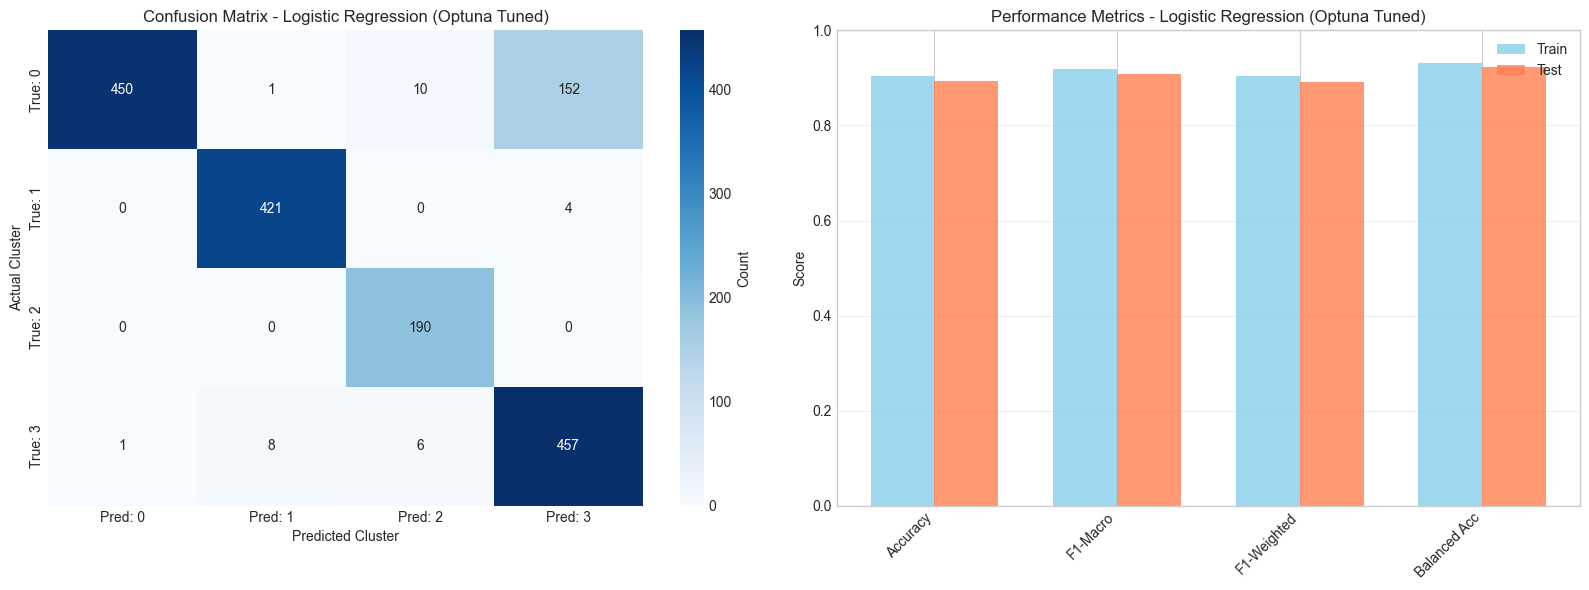


--- PROBABILITY-BASED METRICS (TEST) ---
Log Loss: 0.1857
ROC-AUC (OvR, macro): 0.9857



In [53]:
# Đánh giá model đã tune để có tuned_metrics
tuned_metrics = evaluate_model(
    final_logistic_pipeline, 
    X_train, y_train, 
    X_test, y_test, 
    label="Logistic Regression (Optuna Tuned)"
)


FINAL COMPARISON


,Model,Test F1-Macro,Test Accuracy,N_Features
0,Baseline (all features),0.906787,0.890000,22
1,Optuna Tuned (all features),0.908163,0.892941,22
2,Optuna + Feature Selection (top 4),0.915895,0.897059,4


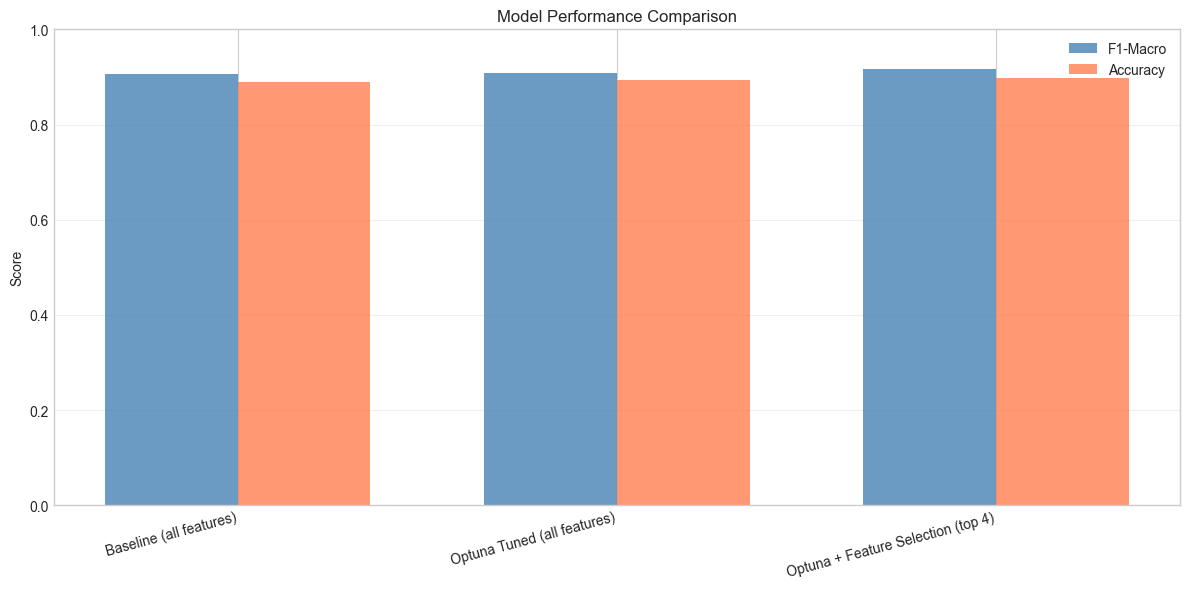

In [54]:
# 5. Final comparison
print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)

comparison_results = pd.DataFrame({
    'Model': [
        'Baseline (all features)',
        'Optuna Tuned (all features)',
        f'Optuna + Feature Selection (top {n_features})'
    ],
    'Test F1-Macro': [
        baseline_metrics['test']['f1_macro'],
        tuned_metrics['test']['f1_macro'],
        fs_metrics['test']['f1_macro']
    ],
    'Test Accuracy': [
        baseline_metrics['test']['accuracy'],
        tuned_metrics['test']['accuracy'],
        fs_metrics['test']['accuracy']
    ],
    'N_Features': [
        len(get_feature_names_from_pipeline(logistic_pipeline)),
        len(get_feature_names_from_pipeline(final_logistic_pipeline)),
        n_features
    ]
})

display(comparison_results)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_results))
width = 0.35

ax.bar(x - width/2, comparison_results['Test F1-Macro'], width, 
       label='F1-Macro', alpha=0.8, color='steelblue')
ax.bar(x + width/2, comparison_results['Test Accuracy'], width, 
       label='Accuracy', alpha=0.8, color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_results['Model'], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## **Best Model Summary**

Surprisingly, the Optimized All-Features Model was the true winner, achieving the highest F1-Score of 91.75%. This happened because keeping every piece of data turned out to be smarter than simplifying it. While the smaller model threw away 'weak' clues, the full model used regularization to simply quiet them down without losing them entirely. This allowed it to capture hidden patterns where small details—useless on their own—became powerful when combined with others. By listening to every signal instead of cutting them out, the model gained the subtle insights needed to solve the most difficult cases